*NLP @ HSE DSBA, autumn 2026. Author: Daria Andreeva*

# Seminar 2 — Language Modelling and Text Generation

Last week we turned a string into a vector and put a classifier on top. The head barely mattered; the representation did all the work. Today, as we promised, we'll continue to the next, more interesting topic, where the string is not the input — it is the output, and the question changes: how do you get a model to produce text at all?

The honest answer is that nothing produces text. Every generator you have ever used — a 1950s n-gram model, the RNN we train today, the LLM in your browser — follows the same idea: once someone thought, that starting the sentence, its words of continuation can be more probable or less probable. For example, for the sentence "yesterday I've been eating at the ..." the continuation "bar" will be more probable, than "wardrobe" or even "watermelon". So as the generation model -- it returns a probability distribution over the next token. The text you see is a next step -- a decision rule that picks tokens out of that distribution one at a time.

### The claim for today:

$$\text{generator} = P(\text{next token} \mid \text{prefix}) \times \text{decoding rule}$$

Both factors are yours to choose, and both change the text you get. The whole field spent sixty years on the left factor and until about 2019 treated the right one as a footnote. We will build the left factor three ways (counting, a recurrent network, an encoder–decoder), the right factor six ways, and watch what each one changes — on one corpus, one test set, one table.

The corpus is 124 000 Russian jokes (анекдоты). They are short, they have a fixed structure, they are impossible to model well, and everybody in the room can tell instantly whether the output is any good. That last property is worth more than any metric today :)

Everything marked 🏠 is fully executable. Nothing is hidden from you. If there are any questions, feel free to ask us!

# Some dependencies

In [1]:
# Colab setup. If needed, uncomment the following lines to install dependencies and clone the repository
#!pip install -q torch tokenizers sacrebleu ipywidgets
#!git clone -q --branch autumn-2026 https://github.com/xufana/dsba_nlp.git
#%cd dsba_nlp/week02_language_modelling

In [1]:
import json
import math
import os
import random
import re
import time
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

warnings.filterwarnings("ignore")

SEED = 42

def seed_all(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_all()

DATA_DIR = "data"
ART_DIR = "artifacts"

# Flip to True to rebuild every precomputed artifact yourself (precompute.py, ~1-2 h on a laptop CPU).
# I will run it without computing the artifacts to save time.
RECOMPUTE = False

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

# Four special tokens, with fixed ids, shared by every model today.
PAD, UNK, BOS, EOS = 0, 1, 2, 3
SPECIALS = ["[PAD]", "[UNK]", "[BOS]", "[EOS]"]

device: mps


# 0. What a language model is, and why it took sixty years

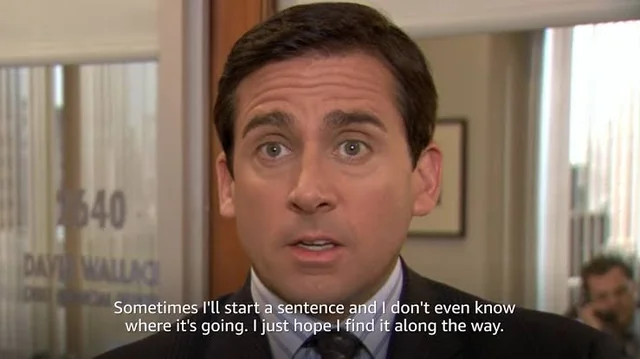


A **language model** is a probability distribution over strings. That is the whole definition — nothing about neural networks, nothing about generation. Given a sequence of tokens $w_1 \dots w_T$, it assigns a number $P(w_1, \dots, w_T)$, and the numbers over all possible sequences sum to one.

Nobody can estimate that joint distribution directly: the number of possible 30-token sentences over an 8 000-token vocabulary is $8000^{30}$. So the first move — Shannon's, in 1948 — is the chain rule:

$$P(w_1, \dots, w_T) = \prod_{t=1}^{T} P(w_t \mid w_1, \dots, w_{t-1})$$

Nothing is lost here; it is an identity. But it changes the question from "how likely is this text" to "**how likely is the next token, given everything so far**" — and *that* question a model can answer one step at a time. Every language model since is a different way to approximate the right-hand side.

Three claims we will check against numbers today:

1. **Perplexity is not a property of a model.** It is a property of a model, a tokenizer and a test set together. Change one and the number changes; compare across them and the number lies.
2. **Better likelihood is not better text.** The most probable continuation under a good model is usually the worst one to show a human.
3. **One vector is not enough.** A sentence squeezed through a fixed-size bottleneck loses exactly the information you need for long inputs — and that failure has a specific shape, which we will plot.

## 0.1 The data

124 000 jokes scraped by a Telegram channel ([source](https://t.me/NeuralShit/2321)). One joke per line-block; we drop anything shorter than 20 characters. Fair warning: the corpus is not curated, so the humour ranges from sharp to crude — as does, therefore, everything our models will generate.

In [2]:
with open(f"{DATA_DIR}/anek.txt", encoding="utf-8") as f:
    raw = f.read()

jokes = [j.strip() for j in raw.strip().replace("<|startoftext|>", "").split("\n\n")]
jokes = [j for j in jokes if len(j) >= 20]

# One shuffle with the seed, then cut: 5 000 test jokes we never train on, 2 000 for validation curves.
# precompute.py uses exactly this split, so every artifact below was trained without seeing `test`.
N_TEST, N_VAL = 5_000, 2_000
idx = np.random.RandomState(SEED).permutation(len(jokes))
test = [jokes[i] for i in idx[:N_TEST]]
val = [jokes[i] for i in idx[N_TEST:N_TEST + N_VAL]]
train = [jokes[i] for i in idx[N_TEST + N_VAL:]]

print(f"train: {len(train):,}   val: {len(val):,}   test: {len(test):,}")
print(f"characters in train: {sum(len(j) for j in train):,}\n")
for j in train[:3]:
    print("•", j, "\n")

train: 117,098   val: 2,000   test: 5,000
characters in train: 12,980,926

• - Чем отличается "прожиточный минимум" в Европе и России?- В Европе он отражает стоимость, при которой еще можно прожить, а в России - стоимость, при которой уже можно умереть. 

• Коли все думают одинаково, значит, никто особенно и не думает. 

• - Вчера на концерте Михаил Поплавский упал в оркестровую яму, и благодарные зрители быстро засыпали яму песком. 



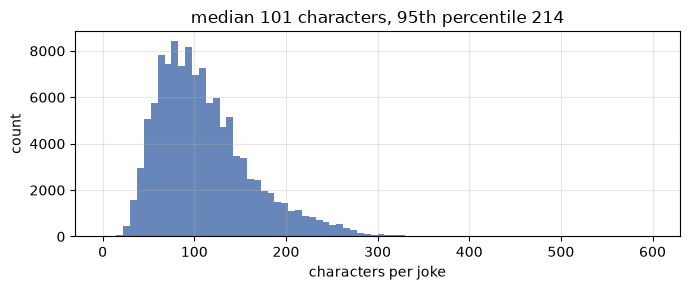

In [3]:
lens = np.array([len(j) for j in train])
plt.figure(figsize=(7, 3))
plt.hist(lens, bins=80, range=(0, 600), color="#4c72b0", alpha=.85)
plt.xlabel("characters per joke"); plt.ylabel("count")
plt.title(f"median {np.median(lens):.0f} characters, 95th percentile {np.percentile(lens, 95):.0f}")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

Short texts, a long tail. That shape is the reason the whole seminar works on a laptop: the model has to hold a hundred characters in mind, not a chapter.

Here is our results table. It is the artefact of the seminar; you will fill it in as we go. Every language model gets one row with the same three numbers, and we will spend a fair amount of time on why the middle two columns are *not* interchangeable.

In [4]:
results = []


def record(model, tokens, test_ppl, bits_per_char, params=None, train_s=None, note=""):
    # Add one row to the running results table.
    results.append({
        "model": model,
        "tokens": tokens,                 # what a "token" is for this row — words, or BPE pieces
        "test_ppl": round(test_ppl, 1),   # perplexity per token, on the 5 000 test jokes
        "bits/char": round(bits_per_char, 3),  # the same number, per character: comparable across tokenizers
        "params": params,
        "train_s": None if train_s is None else round(train_s),
        "note": note,
    })
    return pd.DataFrame(results)


def show_results():
    return pd.DataFrame(results)

## 0.2 Why counting words is not going to be enough

Before any model, try to guess the training set has about 2 million word occurrences. How many *distinct* words is that — and what share of those distinct words occurs exactly once?

word occurrences : 2,029,416
distinct words   : 134,454
seen exactly once: 63,261  (47% of the vocabulary)

most common: ['в', 'и', 'не', 'на', 'что', 'а', 'я', 'с', 'у', 'это', 'как', 'ты']


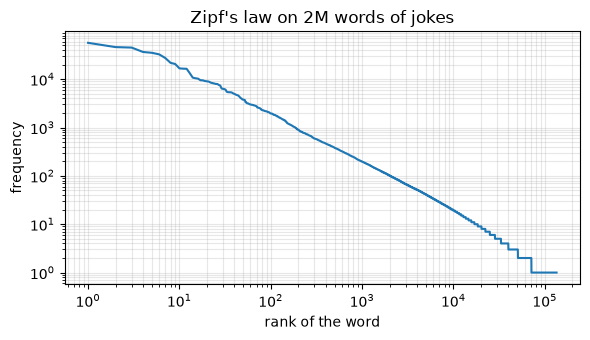

In [6]:
def tokenize_words(text):
    return re.findall(r"\w+", text.lower())

word_counts = Counter(w for j in train for w in tokenize_words(j))
n_tokens = sum(word_counts.values())
hapax = sum(1 for c in word_counts.values() if c == 1)

print(f"word occurrences : {n_tokens:,}")
print(f"distinct words   : {len(word_counts):,}")
print(f"seen exactly once: {hapax:,}  ({hapax / len(word_counts):.0%} of the vocabulary)")
print(f"\nmost common: {[w for w, _ in word_counts.most_common(12)]}")

# Zipf: frequency against rank, both on log axes
freqs = np.array(sorted(word_counts.values(), reverse=True))
plt.figure(figsize=(6, 3.5))
plt.loglog(np.arange(1, len(freqs) + 1), freqs, lw=1.5)
plt.xlabel("rank of the word"); plt.ylabel("frequency"); plt.title("Zipf's law on 2M words of jokes")
plt.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()

Roughly half the vocabulary was seen **once**. Not "rarely" — once. Any estimate of $P(\text{next word} \mid \ldots)$ for those words is a single coin flip, and for the words that will show up in the test set for the first time it is exactly zero.

That straight line on log-log axes is Zipf's law, and it is the bill for working with words as units: no matter how much text you collect, a constant fraction of it is made of things you have never seen before. Russian makes it worse — *кот, кота, коту, котом, коте* are five different words to a word tokenizer.

We have two answers to this, and we will need both: change the unit (block 1) and stop assigning zero to the unseen (block 2).

# 1. Tokenization, for real this time

Last week we looked at what `tiktoken` produces and promised to come back to *how* it is trained. Here it is. Byte-pair encoding (Gage 1994 as a compression trick, Sennrich et al. 2016 as a tokenizer) is a greedy algorithm you can write in twenty lines, and it is the tokenizer under every model you use.

The idea: start from characters, so nothing is ever out of vocabulary. Then, repeatedly, find the pair of adjacent units that occurs most often in the corpus and glue it into a new unit. Stop when the vocabulary is as big as you want. Frequent words end up as one token; rare words end up as several familiar pieces; a word nobody has ever seen still tokenizes, into characters if it must.

## 1.1 BPE in twenty lines

Your choice: what will the very first merge be on a Russian corpus? (A pair of letters. Which one?)

In [8]:
def bpe_train(texts, num_merges, verbose=10):
    # Every word becomes a tuple of characters plus an end-of-word marker "</w>",
    # weighted by how often the word occurs. The marker matters: it glues to the
    # word's last character, so a word-final "ов" (a case ending) is a different
    # pair from a word-internal "ов", and only the former can ever merge with it.
    # We only ever merge inside words, since each word is counted separately.
    word_freq = Counter()
    for text in texts:
        for w in tokenize_words(text):
            word_freq[tuple(w) + ("</w>",)] += 1

    merges = []
    for i in range(num_merges):
        # 1. count every adjacent pair, weighted by word frequency
        pairs = Counter()
        for word, freq in word_freq.items():
            for a, b in zip(word, word[1:]):
                pairs[(a, b)] += freq
        if not pairs:
            break
        best = max(pairs, key=pairs.get)

        # 2. glue that pair everywhere it occurs
        new_word_freq = Counter()
        for word, freq in word_freq.items():
            out, j = [], 0
            while j < len(word):
                if j < len(word) - 1 and (word[j], word[j + 1]) == best:
                    out.append(word[j] + word[j + 1]); j += 2
                else:
                    out.append(word[j]); j += 1
            new_word_freq[tuple(out)] += freq
        word_freq = new_word_freq
        merges.append(best)
        if i < verbose:
            print(f"merge {i + 1:3d}: {best[0]!r} + {best[1]!r} -> {best[0] + best[1]!r}   (seen {pairs[best]:,} times)")
    return merges


t = time.time()
merges = bpe_train(train[:3_000], num_merges=300)
print(f"\n300 merges on 3 000 jokes: {time.time() - t:.1f}s")

merge   1: 'а' + '</w>' -> 'а</w>'   (seen 6,488 times)
merge   2: 'е' + '</w>' -> 'е</w>'   (seen 5,912 times)
merge   3: 'о' + '</w>' -> 'о</w>'   (seen 5,664 times)
merge   4: 'и' + '</w>' -> 'и</w>'   (seen 4,537 times)
merge   5: 'я' + '</w>' -> 'я</w>'   (seen 3,617 times)
merge   6: 'ь' + '</w>' -> 'ь</w>'   (seen 3,342 times)
merge   7: 'т' + '</w>' -> 'т</w>'   (seen 3,252 times)
merge   8: 'с' + 'т' -> 'ст'   (seen 2,805 times)
merge   9: 'у' + '</w>' -> 'у</w>'   (seen 2,649 times)
merge  10: 'п' + 'о' -> 'по'   (seen 2,562 times)

300 merges on 3 000 jokes: 6.6s


The first merges are not words. They are the most frequent letter pairs in Russian — the end of a word attached to its last letter, the commonest bigrams — and only after a few dozen merges do whole short words (*не, что, это*) appear. The algorithm has no idea what a word is. It only counts.

That "end of a word" is the `</w>` symbol we appended to every word before training. It is not decoration: without it, a word-final letter sequence and the same letters occurring inside a word would be the same pair to the counter, and the algorithm would happily merge across that distinction. With `</w>` attached to the last character, a suffix like a case ending only ever merges with its neighbor *at the end of a word* — which is exactly why the early merges above read as "letter + last-letter-of-word" rather than "letter + letter" at random.

Applying the merges is the same loop in the same order:

In [10]:
def bpe_encode(word, merges):
    pieces = list(word) + ["</w>"]
    for a, b in merges:                     # same order as in training — the order *is* the model
        j = 0
        while j < len(pieces) - 1:
            if pieces[j] == a and pieces[j + 1] == b:
                pieces[j:j + 2] = [a + b]
            else:
                j += 1
    return pieces

for w in ["мужик", "мужика", "мужиками", "штирлиц", "программист", "инквизиция"]:
    print(f"{w:14s} -> {bpe_encode(w, merges)}")

мужик          -> ['муж', 'и', 'к</w>']
мужика         -> ['муж', 'и', 'ка</w>']
мужиками       -> ['муж', 'и', 'ка', 'ми</w>']
штирлиц        -> ['ш', 'ти', 'р', 'ли', 'ц</w>']
программист    -> ['про', 'гра', 'м', 'ми', 'с', 'т</w>']
инквизиция     -> ['ин', 'к', 'в', 'из', 'и', 'ци', 'я</w>']


Three things fall out of the output:

* *мужик* is one piece; its case forms are the same piece plus a suffix. That is Russian morphology recovered from statistics alone, and it is the reason the Zipf tail hurts less: the model sees *мужик* in all five forms and can share what it learns.
* *инквизиция* is shredded into eight pieces, because 3 000 jokes do not mention the Inquisition much. Rare words are expensive — in sequence length, not in vocabulary.
* Nothing is `[UNK]`, and nothing ever will be. The characters are always in the vocabulary.

❓ **Open question 1:** the merge order is learned on the *training* corpus. What happens to a text from a very different domain — legal Russian, or English? It will tokenize; will it tokenize *well*, and what does "well" even mean for a tokenizer?

## 1.2 The same thing, from a library

The twenty-line version takes minutes on the full corpus because Python. The `tokenizers` library (Rust underneath) does the identical algorithm in a few seconds, and adds two details worth naming:

* a **pre-tokenizer** decides where merges are *not* allowed to cross. Ours marks the start of every word with `▁` (that is what makes decoding reversible — spaces are recoverable) and splits punctuation off, so `,` never gets glued onto a word;
* **special tokens** with fixed ids: `[PAD]` for batching, `[BOS]`/`[EOS]` to mark where a text starts and ends, `[UNK]` which, with a character-level alphabet, we should never see.

In [11]:
from tokenizers import Tokenizer, models, pre_tokenizers, decoders, trainers


def train_bpe(texts, vocab_size):
    tok = Tokenizer(models.BPE(unk_token="[UNK]"))
    # Metaspace marks word starts with ▁ (reversible), Punctuation splits ",", "-", "?" off words.
    tok.pre_tokenizer = pre_tokenizers.Sequence([pre_tokenizers.Metaspace(), pre_tokenizers.Punctuation()])
    tok.decoder = decoders.Metaspace()
    trainer = trainers.BpeTrainer(vocab_size=vocab_size, special_tokens=SPECIALS, show_progress=False)
    tok.train_from_iterator(texts, trainer)
    return tok


t = time.time()
tok_live = train_bpe(train, vocab_size=8_000)
print(f"BPE with 8 000 tokens on {len(train):,} jokes: {time.time() - t:.1f}s\n")

sample = train[7]
enc = tok_live.encode(sample)
print(sample)
print(enc.tokens)
print("\nround trip identical:", tok_live.decode(enc.ids) == sample)

BPE with 8 000 tokens on 117,098 jokes: 1.5s

Чем больше смотрю в зеркало, тем больше верю Дарвину!
['▁Чем', '▁больше', '▁смотрю', '▁в', '▁зеркало', ',', '▁тем', '▁больше', '▁верю', '▁Да', 'р', 'ви', 'ну', '!']

round trip identical: True


## 1.3 Vocabulary size is a dial, not a fact

Characters give you a vocabulary of ~150 and sequences of a hundred tokens per joke. Words give you 200 000 types and sequences of twenty. BPE puts a dial between the two, and where you set it is a trade: every token the model has to predict is a step of computation and a place to make a mistake; every token you add to the vocabulary is a row of the embedding matrix that needs enough data to train.

**Bet:** going from a 1 000-token vocabulary to 32 000, how much shorter does the average joke get — 2×? 5×?

In [12]:
rows = []
probe = test[:2_000]
n_words = sum(len(tokenize_words(j)) for j in probe)
n_chars = sum(len(j) for j in probe)

for V in [500, 1_000, 2_000, 4_000, 8_000, 16_000, 32_000]:
    t = time.time()
    tk = train_bpe(train, V)
    fit_s = time.time() - t
    n_tok = sum(len(e.ids) for e in tk.encode_batch(probe))
    rows.append({"vocab": V, "tokens/joke": n_tok / len(probe), "tokens/word": n_tok / n_words,
                 "chars/token": n_chars / n_tok, "fit_s": round(fit_s, 1)})

# the two ends of the dial, for reference
rows.append({"vocab": "chars", "tokens/joke": n_chars / len(probe), "tokens/word": n_chars / n_words, "chars/token": 1.0, "fit_s": 0})
test_words = [w for j in probe for w in tokenize_words(j)]
oov = sum(1 for w in test_words if w not in word_counts) / len(test_words)
rows.append({"vocab": f"words ({len(word_counts):,})", "tokens/joke": n_words / len(probe), "tokens/word": 1.0,
             "chars/token": n_chars / n_words, "fit_s": 0, "OOV on test": f"{oov:.1%}"})

dial = pd.DataFrame(rows)
dial

,vocab,tokens/joke,tokens/word,chars/token,fit_s,OOV on test
0,500,58.2335,3.411153,1.877725,1.1,NaN
1,1000,48.1890,2.822775,2.269117,1.1,NaN
2,2000,41.7130,2.443429,2.621401,1.2,NaN
3,4000,36.8150,2.156518,2.970162,1.1,NaN
4,8000,32.8970,1.927013,3.323905,1.2,NaN
5,16000,29.8615,1.749202,3.661789,1.4,NaN
6,32000,27.6230,1.618077,3.958531,1.7,NaN
7,chars,109.3465,6.405208,1.000000,0.0,NaN
8,"words (134,454)",17.0715,1.000000,6.405208,0.0,3.2%


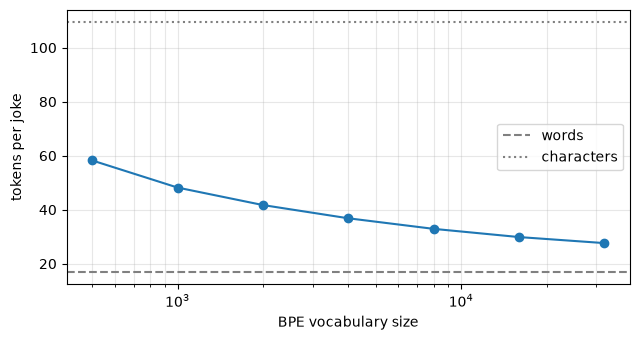

In [13]:
d = dial[dial.vocab.apply(lambda v: isinstance(v, int))]
plt.figure(figsize=(6.5, 3.5))
plt.semilogx(d.vocab, d["tokens/joke"], "o-")
plt.axhline(n_words / len(probe), ls="--", color="gray", label="words")
plt.axhline(n_chars / len(probe), ls=":", color="gray", label="characters")
plt.xlabel("BPE vocabulary size"); plt.ylabel("tokens per joke")
plt.legend(); plt.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()

Read the table rather than skimming it:

* A 32 000-token vocabulary is **not** four times more efficient than an 8 000 one. The curve flattens: the frequent words were already single tokens at 8 000, and the extra 24 000 slots go to rare words that barely appear. Every one of those rows in the embedding matrix will be trained on a handful of examples.
* At 8 000 tokens a joke costs about 1.4 tokens per word. Compare last week's `tiktoken` experiment: a tokenizer trained *on Russian* pays far less for Russian than one trained mostly on English. The "Russian is expensive" result was about the training corpus, not the alphabet.
* A word vocabulary has 6% of test tokens out of vocabulary. A BPE vocabulary has exactly zero, at any size.

We will use **8 000** for the rest of the day. Not because it is optimal — because it is a reasonable point on the curve, and the perplexities below are only comparable if every neural model shares one tokenizer.

The recipe above is deterministic, but the model weights we load later were trained against one specific vocabulary, so we load that saved copy rather than trusting two runs to agree to the last merge.

In [14]:
if RECOMPUTE:
    !python precompute.py --data-dir data --out artifacts --only tokenizers

tok = Tokenizer.from_file(f"{ART_DIR}/bpe_jokes_8k.json")
V = tok.get_vocab_size()
print(f"vocabulary: {V:,} tokens; specials: {[tok.id_to_token(i) for i in range(4)]}")
print(f"same vocabulary as the one trained live: {tok.get_vocab() == tok_live.get_vocab()}")


def tokenize_bpe(text):
    # tokens as strings — for the count-based models in block 2
    return tok.encode(text).tokens

vocabulary: 8,000 tokens; specials: ['[PAD]', '[UNK]', '[BOS]', '[EOS]']
same vocabulary as the one trained live: True


# 2. Counting: the n-gram language model

The chain rule needs $P(w_t \mid w_1, \dots, w_{t-1})$ — a distribution conditioned on the *entire* prefix. Nobody has counts for entire prefixes; most 12-token prefixes in the test set have never occurred anywhere. So the second move is an approximation, the **Markov assumption**: only the last $n-1$ tokens matter.

$$P(w_t \mid w_1, \dots, w_{t-1}) \approx P(w_t \mid w_{t-n+1}, \dots, w_{t-1})$$

This is a lie, and a useful one. With $n = 3$ the model needs counts of triples, and triples we have. The estimate is the obvious one — the maximum-likelihood ratio of counts:

$$P(w_t \mid \text{prefix}) = \frac{\text{Count}(\text{prefix}, w_t)}{\sum_{w \in V} \text{Count}(\text{prefix}, w)}$$

Two bookkeeping details that every implementation needs. We pad the start of each text with $n-1$ copies of `[BOS]`, so that the first real token also has a full-length prefix. And we append `[EOS]` and treat it as an ordinary token, so the model can learn *when a joke ends* — otherwise it could never stop generating.

🎯 **Live:** count the n-grams. One dictionary: prefix tuple → counter of what followed it.

In [15]:
BOS_TOK, EOS_TOK, UNK_TOK = "[BOS]", "[EOS]", "[UNK]"


def count_ngrams(corpus_tokens, n):
    '''
    corpus_tokens: list of token lists (one per text)
    returns: {tuple(prefix of n-1 tokens): Counter({next_token: count})}
    Pad the start with [BOS], append [EOS] and count it like any other token.
    '''
    counts = defaultdict(Counter)
    for tokens in corpus_tokens:
        padded = [BOS_TOK] * (n - 1) + tokens + [EOS_TOK]
        # YOUR CODE HERE
        for i in range(n - 1, len(padded)):
            counts[tuple(padded[i - n + 1:i])][padded[i]] += 1
    return counts


toy = [tokenize_words(j) for j in train[:5]]
toy_counts = count_ngrams(toy, n=3)

print(train[0], "\n")
print("after ('[BOS]', '[BOS]'):", dict(toy_counts[(BOS_TOK, BOS_TOK)]))
some_prefix = next(p for p in toy_counts if BOS_TOK not in p)
print(f"after {some_prefix}:", dict(toy_counts[some_prefix]))

- Чем отличается "прожиточный минимум" в Европе и России?- В Европе он отражает стоимость, при которой еще можно прожить, а в России - стоимость, при которой уже можно умереть. 

after ('[BOS]', '[BOS]'): {'чем': 1, 'коли': 1, 'вчера': 1, 'это': 1, 'ты': 1}
after ('чем', 'отличается'): {'прожиточный': 1}


Now the model. It stores counts for **every order up to `max_n`**, so that one object can answer as a unigram, bigram or 5-gram model — we will need that in 2.3, when we start mixing orders.

In [16]:
class NGramLM:
    '''Count-based language model over string tokens.

    prob(token, prefix, n, delta, interpolate):
      n            order to use (<= max_n)
      delta        add-delta smoothing; 0 = raw maximum likelihood
      interpolate  mix orders n, n-1, ..., 1 with fixed weights (halving each step down)
    '''

    def __init__(self, corpus_tokens, max_n=3):
        self.max_n = max_n
        self.counts = {k: count_ngrams(corpus_tokens, k) for k in range(1, max_n + 1)}
        self.totals = {k: {p: sum(c.values()) for p, c in self.counts[k].items()} for k in self.counts}
        self.vocab = set(self.counts[1][()]) | {UNK_TOK}
        self.V = len(self.vocab)

    def _p(self, k, prefix, token, delta):
        # P_k(token | last k-1 tokens of prefix), add-delta smoothed
        pre = prefix[len(prefix) - (k - 1):] if k > 1 else ()
        total = self.totals[k].get(pre, 0)
        if total == 0 and delta == 0:
            return 0.0
        cnt = self.counts[k][pre].get(token, 0) if total else 0
        return (cnt + delta) / (total + delta * self.V)

    def prob(self, token, prefix, n, delta=0.0, interpolate=False):
        prefix = tuple(([BOS_TOK] * (n - 1) + list(prefix))[-(n - 1):]) if n > 1 else ()
        if not interpolate:
            return self._p(n, prefix, token, delta)
        weights = np.array([0.5 ** i for i in range(n)]); weights /= weights.sum()
        return sum(w * self._p(k, prefix, token, delta) for w, k in zip(weights, range(n, 0, -1)))

    def next_distribution(self, prefix, n, delta=0.0, interpolate=False):
        # {token: P(token | prefix)} over the whole vocabulary (or only the seen continuations if delta = 0)
        prefix_t = tuple(([BOS_TOK] * (n - 1) + list(prefix))[-(n - 1):]) if n > 1 else ()
        if delta == 0 and not interpolate:
            cand = self.counts[n].get(prefix_t, {})
            total = self.totals[n].get(prefix_t, 0)
            return {t: c / total for t, c in cand.items()} if total else {}
        return {t: self.prob(t, prefix, n, delta, interpolate) for t in self.vocab}


# N-gram counts are memory-hungry (a dict of every prefix seen); for the demo we count on a
# subset of the jokes. It changes the perplexities only slightly and keeps the notebook under ~3 GB.
NGRAM_JOKES = 40_000
t = time.time()
train_words = [tokenize_words(j) for j in train]            # full corpus, for the sparsity plot below
lm_words = NGramLM(train_words[:NGRAM_JOKES], max_n=3)
print(f"counted 1-, 2- and 3-grams over {sum(len(x) for x in train_words[:NGRAM_JOKES]):,} words in {time.time() - t:.0f}s")
print(f"distinct bigram prefixes: {len(lm_words.counts[2]):,}   distinct trigram prefixes: {len(lm_words.counts[3]):,}")

counted 1-, 2- and 3-grams over 692,177 words in 2s
distinct bigram prefixes: 77,607   distinct trigram prefixes: 404,617


## 2.1 First text

The model returns a distribution; to get text we have to *pick* from it, one token at a time, feeding each choice back in as context. That is **autoregressive generation** (you can find the same concept under the name of `seq2seq`) and it is the primary way anybody generates text today, LLMs included. Here we pick by sampling from the distribution as it is — block 4 is entirely about the other ways to pick.

In [19]:
def generate_ngram(lm, prefix="", n=3, delta=0.0, interpolate=False, max_len=60, seed=None, tokenize=tokenize_words):
    rng = np.random.RandomState(seed)
    tokens = tokenize(prefix) if prefix else []
    for _ in range(max_len):
        dist = lm.next_distribution(tokens, n, delta, interpolate)
        if not dist:                                   # dead end: a prefix we never saw
            tokens.append("⟂"); break
        cand, p = zip(*dist.items())
        nxt = rng.choice(cand, p=np.array(p) / sum(p))
        if nxt == EOS_TOK:
            break
        tokens.append(nxt)
    return " ".join(tokens)


for s in range(3):
    print("•", generate_ngram(lm_words, n=3, seed=s), "\n")

• деньги навоз сегодня нет а где глаз 

• встречаются две подруги разговаривают слушай если я пожарю картошечку как ты колька умудрился с велосипеда так упасть руки то помнят пока не нашли в моей сумочке что то с внутренней стороны крышки 

• чтобы быть накормленными и обласкаными потом они считают что в воде не подходит ну он в устной форме докладывает полковнику 



Locally, the text is fine — every three words in a row were once in a real joke. Globally, it is nothing: the model forgets what the joke was about two words after saying it, because it *cannot* remember it. That is not a bug in the trigram model. It is the Markov assumption, doing exactly what it said it would.

So, what happens with a 5-gram model — better jokes, or something else?

In [20]:
lm_words5 = NGramLM(train_words[:NGRAM_JOKES], max_n=5)
for s in range(3):
    print("•", generate_ngram(lm_words5, n=5, seed=s), "\n")

• деньги навоз сегодня нет а завтра долгов воз 

• встречаются две подруги рассказивают о своей семейной жизни у нас с мужем все хорошо он не пьет не курит не играет на скачках никогда не спорит и не существует 

• чтобы быть поближе к народу власти не обязательно у него красть 



In [21]:
def copied_from_train(text, n=8):
    # is there an 8-word window of the generated text that occurs verbatim in the training corpus?
    toks = text.split()
    windows = {" ".join(toks[i:i + n]) for i in range(len(toks) - n + 1)}
    return any(w in train_joined for w in windows)

train_joined = "\n".join(" ".join(tokenize_words(j)) for j in train)
for n in [3, 5]:
    lm_ = lm_words if n == 3 else lm_words5
    copied = np.mean([copied_from_train(generate_ngram(lm_, n=n, seed=s, max_len=40)) for s in range(30)])
    print(f"{n}-gram: {copied:.0%} of samples contain an 8-word run copied verbatim from training")

3-gram: 30% of samples contain an 8-word run copied verbatim from training
5-gram: 90% of samples contain an 8-word run copied verbatim from training


The 5-gram output reads *much* better — and most of it is a training joke, recited. With 2 million words there are almost no 4-word prefixes that were seen more than once, so "the distribution over the next word" is usually a single option, and sampling from it is table lookup. The model has not learned jokes; it has memorised them.

This is the n-gram dilemma in one experiment. Small $n$: coherent for three words, then nonsense. Large $n$: coherent because it is quoting. There is no setting in between where it *generalises*, because counting cannot generalise: it has no notion that two prefixes are similar. Neural models exist to fix exactly that, and we get there in block 3. But first we need a number.

## 2.2 Perplexity

Looking at samples is not a metric. The metric for a language model is how much probability it assigns to text it has not seen — the test set — and by convention we report it as **perplexity**:

$$\text{PPL}(w_1 \dots w_T) = P(w_1, \dots, w_T)^{-1/T} = \exp\Big(-\frac{1}{T}\sum_{t=1}^{T} \log P(w_t \mid w_{<t})\Big)$$

Read the right-hand side: it is $\exp$ of the average negative log-likelihood per token, i.e. $\exp$ of the **cross-entropy** — the exact quantity a neural network will minimise as its training loss in block 3. Lower is better.

The name comes from the intuition. If the model were uniformly unsure between $k$ tokens at every step, its perplexity would be exactly $k$. So a perplexity of 60 means "on average, the model is as confused as if it were choosing among 60 equally likely tokens". It is the *effective branching factor* of the text under the model.

📌 **Bet:** before running it — what will the unsmoothed trigram model's perplexity on the test set be?

In [24]:
def evaluate_ngram(lm, texts, tokenize, n, delta=0.0, interpolate=False):
    '''Returns (perplexity per token, bits per character) on a list of texts.'''
    nll, n_tok, n_chars = 0.0, 0, 0
    for text in texts:
        tokens = [t if t in lm.vocab else UNK_TOK for t in tokenize(text)] + [EOS_TOK]
        for i, tok_ in enumerate(tokens):
            p = lm.prob(tok_, tokens[:i], n, delta, interpolate)
            nll -= math.log(p) if p > 0 else float("-inf")
        n_tok += len(tokens)
        n_chars += len(text)
    return math.exp(nll / n_tok), nll / n_chars / math.log(2)


ppl, bpc = evaluate_ngram(lm_words, test, tokenize_words, n=3)
print(f"trigram, words, no smoothing: perplexity = {ppl}")

trigram, words, no smoothing: perplexity = inf


**Infinity.** Not a large number — infinity. One unseen trigram anywhere in 5 000 jokes gives $P = 0$ for that token, $\log 0 = -\infty$ for the sum, and the whole test set is "impossible" according to the model.

How often does this happen? Let us count, for each $n$, the share of test n-grams that never occurred in training:

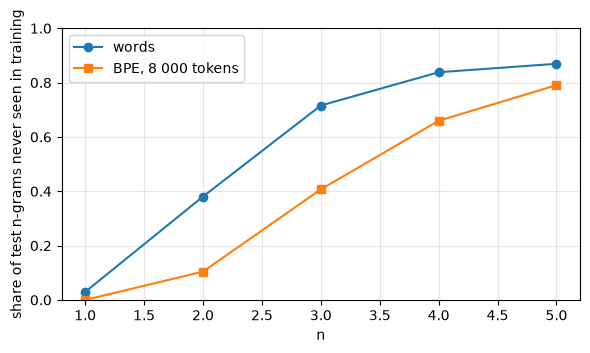

,words,BPE 8k
n,,
1,2.9%,0.0%
2,38.1%,10.4%
3,71.6%,40.7%
4,83.8%,66.0%
5,86.9%,79.0%


In [22]:
def unseen_share(train_tok, test_tok, n):
    seen = set()
    for toks in train_tok:
        padded = [BOS_TOK] * (n - 1) + toks + [EOS_TOK]
        seen.update(zip(*[padded[i:] for i in range(n)]))
    total = unseen = 0
    for toks in test_tok:
        padded = [BOS_TOK] * (n - 1) + toks + [EOS_TOK]
        for g in zip(*[padded[i:] for i in range(n)]):
            total += 1
            unseen += g not in seen
    return unseen / total


test_words = [tokenize_words(j) for j in test]
train_bpe = [tokenize_bpe(j) for j in train]
test_bpe = [tokenize_bpe(j) for j in test]

ns = [1, 2, 3, 4, 5]
sparsity = pd.DataFrame({
    "n": ns,
    "words": [unseen_share(train_words, test_words, n) for n in ns],
    "BPE 8k": [unseen_share(train_bpe, test_bpe, n) for n in ns],
})

plt.figure(figsize=(6, 3.5))
plt.plot(sparsity.n, sparsity.words, "o-", label="words")
plt.plot(sparsity.n, sparsity["BPE 8k"], "s-", label="BPE, 8 000 tokens")
plt.xlabel("n"); plt.ylabel("share of test n-grams never seen in training")
plt.ylim(0, 1); plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
sparsity.set_index("n").style.format("{:.1%}")

This plot is the reason the rest of the seminar exists.

* At $n = 1$ the word model already has a few percent of test tokens it has never seen (the OOV rate from block 1); the BPE model has none — that is what subwords bought us.
* At $n = 3$ roughly a third of the test trigrams are new. At $n = 5$, almost all of them. Ten times more data would move these points a little; it would not change the shape, because the number of possible n-grams grows exponentially with $n$ and the corpus grows linearly.
* BPE makes it worse per token: pieces are shorter than words, so an $n$-token window covers less text and is shared *more*, but there are also more windows to get wrong. The tokenizer changed the units; it did not change the problem.

The problem has a name — **sparsity** — and the classical fix is to stop trusting the counts.

## 2.3 Smoothing: stop assigning zero

Every smoothing method is the same idea: take a little probability mass away from the n-grams you have seen and spread it over the ones you have not. They differ in how much and how cleverly.

**Add-$\delta$ (Laplace) smoothing** pretends every possible continuation was seen $\delta$ extra times:

$$P(w_t \mid \text{prefix}) = \frac{\text{Count}(\text{prefix}, w_t) + \delta}{\sum_{w \in V}\text{Count}(\text{prefix}, w) + \delta\,|V|}$$

Nothing is zero any more. The cost is in the denominator: with $|V| = 200\,000$ words and $\delta = 1$, a prefix seen 10 times gets $200\,010$ added to its total, and the ten real observations are drowned by two hundred thousand imaginary ones.

**Interpolation** (Jelinek–Mercer 1980) is the smarter move: when the trigram estimate is unreliable, lean on the bigram, and behind it the unigram:

$$P(w_t \mid w_{t-2}, w_{t-1}) = \lambda_3 P_3(w_t \mid w_{t-2}, w_{t-1}) + \lambda_2 P_2(w_t \mid w_{t-1}) + \lambda_1 P_1(w_t), \qquad \sum \lambda_i = 1$$

Our `NGramLM` does this with fixed weights halving with each order down; the proper method fits the $\lambda$s on held-out data. The best classical method, **Kneser–Ney**, also changes *what* the lower-order model estimates (how many different contexts a word appears in, rather than how often) — it was the state of the art for twenty years and is still the right baseline to beat. We will not implement it; `nltk.lm` and KenLM have.

**Bet:** three questions, write down all three.

(1) Which $n$ wins once we smooth — 2, 3 or 5?

(2) Is Laplace with $\delta = 1$ better or worse than $\delta = 0.01$?

(3) Does interpolation beat the best single-order model?

In [25]:
configs = [
    ("1-gram", 1, 0.01, False),
    ("2-gram, add-1", 2, 1.0, False),
    ("2-gram, add-0.01", 2, 0.01, False),
    ("3-gram, add-1", 3, 1.0, False),
    ("3-gram, add-0.01", 3, 0.01, False),
    ("2-gram, interpolated", 2, 0.01, True),
    ("3-gram, interpolated", 3, 0.01, True),
    ("5-gram, interpolated", 5, 0.01, True),
]

rows = []
for name, n, delta, interp in configs:
    lm_ = lm_words5 if n > 3 else lm_words
    t = time.time()
    ppl, bpc = evaluate_ngram(lm_, test, tokenize_words, n, delta, interp)
    rows.append({"model": name, "test_ppl": round(ppl, 1), "bits/char": round(bpc, 3), "eval_s": round(time.time() - t, 1)})
ngram_table = pd.DataFrame(rows)
ngram_table

,model,test_ppl,bits/char,eval_s
0,1-gram,4398.3,2.001,0.1
1,"2-gram, add-1",21528.8,2.380,0.1
2,"2-gram, add-0.01",5843.1,2.069,0.1
3,"3-gram, add-1",51970.6,2.590,0.1
4,"3-gram, add-0.01",27980.1,2.443,0.1
5,"2-gram, interpolated",2203.5,1.836,0.3
6,"3-gram, interpolated",3109.1,1.918,0.4
7,"5-gram, interpolated",7062.4,2.114,0.7


Read the table honestly:

* **Add-1 is a disaster** and gets worse with $n$: the 3-gram with $\delta = 1$ is worse than the unigram. Two hundred thousand imaginary observations per prefix flatten every distribution toward uniform. Add-0.01 is far better — the smoothing constant is a hyperparameter, and the textbook value of 1 is the wrong one on any realistic vocabulary.
* **Interpolation wins**, and it wins by letting the model fall back gracefully: when the trigram has never seen the prefix, the bigram usually has.
* **The 5-gram does not win.** Even interpolated, the extra orders mostly add noise: the 4- and 5-gram counts are almost all ones (look at the sparsity plot again). More context is only useful if you have the data to estimate it, and we have 2 million words. This is the ceiling of counting.

Now, the same experiment on BPE tokens — the units every neural model in the rest of the notebook will use:

In [26]:
t = time.time()
lm_bpe = NGramLM(train_bpe[:NGRAM_JOKES], max_n=5)
print(f"counted 1..5-grams over {sum(len(x) for x in train_bpe[:NGRAM_JOKES]):,} BPE tokens in {time.time() - t:.0f}s\n")

rows = []
for name, n, delta, interp in [("2-gram, interpolated", 2, 0.01, True),
                               ("3-gram, interpolated", 3, 0.01, True),
                               ("5-gram, interpolated", 5, 0.01, True)]:
    ppl, bpc = evaluate_ngram(lm_bpe, test, tokenize_bpe, n, delta, interp)
    rows.append({"model": name, "test_ppl": round(ppl, 1), "bits/char": round(bpc, 3)})
ngram_table_bpe = pd.DataFrame(rows)

print("words:"); display(ngram_table[ngram_table.model.str.contains("interpolated")].set_index("model"))
print("BPE 8k:"); display(ngram_table_bpe.set_index("model"))

counted 1..5-grams over 1,331,690 BPE tokens in 5s

words:


,test_ppl,bits/char,eval_s
model,,,
"2-gram, interpolated",2203.5,1.836,0.3
"3-gram, interpolated",3109.1,1.918,0.4
"5-gram, interpolated",7062.4,2.114,0.7


BPE 8k:


,test_ppl,bits/char
model,,
"2-gram, interpolated",200.7,2.374
"3-gram, interpolated",210.9,2.396
"5-gram, interpolated",469.0,2.753


## 2.4 The number that lies

Look at the two `test_ppl` columns. The BPE trigram has a perplexity several times *lower* than the word trigram. Is it a better model?

No. It is the same algorithm on the same text. What changed is **what a token is**. Predicting a subword piece is an easier task than predicting a whole word — there are fewer plausible options, and half the time the next piece is the obvious end of the current word. Per-token perplexity rewards you for cutting the text finer, and it rewards you for nothing. So per-token perplexity is useless for comparing across tokenizers.

The fix is to divide the same negative log-likelihood by the number of *characters* instead of tokens — characters do not depend on the tokenizer. That is the `bits/char` column, and it is a real quantity in its own right: how many bits per character an ideal compressor built on this model would need. (A language model *is* a compressor, and the best text compressors are language models.)

But read that column carefully, because it contains a second trap. The word trigram's `bits/char` comes out *lower* than the BPE trigram's — which would say the word model is the better compressor. It is not. The word tokenizer is `re.findall(r"\w+")`: it throws away every space and punctuation mark — roughly one character in five — and the word model is therefore never charged for predicting them. Divide its (smaller) description length by the (full) character count and you get a flattering number for a model that is simply *modelling less of the string*. Charge each model only for the characters it actually accounts for and the two trigrams are neck and neck. The BPE tokenization is reversible — it covers **every** character, spaces included — so within the BPE family `bits/char` is honest and comparable, and across a lossy tokenizer it is not.

> **Even bits/char is only fair when the models account for the same string.** Perplexity is comparable only under the same tokenizer and test set; bits/char lifts the tokenizer restriction *only* for models that are lossless over the text. For everything in the rest of this notebook we use one reversible BPE tokenizer, so the numbers are finally comparable — and the honest yardstick is the **BPE family**.

So our baseline to beat is the row that is both fair and strong: the interpolated **BPE trigram**. Keep its `test_ppl` and `bits/char` in mind — a well-smoothed count model is not a weak opponent, and the next block finds out whether a small, briefly-trained network actually clears it.

In [27]:
r = ngram_table.set_index("model").loc["3-gram, interpolated"]
record("3-gram, interpolated", "words", r.test_ppl, r["bits/char"], params=f"{sum(len(c) for c in lm_words.counts[3].values()):,} counts", note="count-based")
r = ngram_table_bpe.set_index("model").loc["3-gram, interpolated"]
record("3-gram, interpolated", "BPE 8k", r.test_ppl, r["bits/char"], params=f"{sum(len(c) for c in lm_bpe.counts[3].values()):,} counts", note="count-based")
show_results()

,model,tokens,test_ppl,bits/char,params,train_s,note
0,"3-gram, interpolated",words,3109.1,1.918,"622,154 counts",None,count-based
1,"3-gram, interpolated",BPE 8k,210.9,2.396,"865,574 counts",None,count-based


❓ **Open question 2:** we evaluated on 5 000 held-out jokes from the *same* channel. A joke from a different site, written in 2005, will have a higher perplexity under every model here. Is that a fact about the model or about the joke? What would you have to hold fixed to make "model A is better than model B" a meaningful sentence?

*(Housekeeping: the count models above hold millions of n-grams in RAM and we are done with them. We free them before the neural blocks so the notebook stays light — the neural models are tiny by comparison.)*

In [28]:
import gc
del lm_words, lm_words5, lm_bpe, train_bpe
gc.collect()

0

# 3. Learning: recurrent language models

Counting has a ceiling and we just hit it. The reason is not the amount of data; it is that a count-based model treats every prefix as an unrelated symbol. *Штирлиц открыл* and *Мюллер открыл* share nothing — even though whatever follows one probably follows the other. Counts cannot generalise, because they have no notion of similarity between contexts.

Last week gave us the tool for that: **embeddings**. Bengio et al. (2003) built the first neural language model by concatenating the embeddings of the last $n-1$ words and putting a network on top — the same Markov assumption, but now *cat* and *dog* share statistics through their vectors. It beat the best smoothed n-grams, and it still had a fixed window.

The **recurrent** network (Elman 1990; as a language model, Mikolov et al. 2010) drops the window. Instead of looking at the last $n-1$ tokens, it maintains a state vector $h_t$ that is updated once per token and is supposed to summarise *everything so far*:

$$h_t = f(h_{t-1}, x_t), \qquad P(w_{t+1} \mid w_{\le t}) = \text{softmax}(W h_t)$$

Same chain rule, same next-token prediction, but the context is — in principle — unbounded. In practice it is bounded by how much a 256-dimensional vector can hold and by how far a gradient can travel; we will measure both.

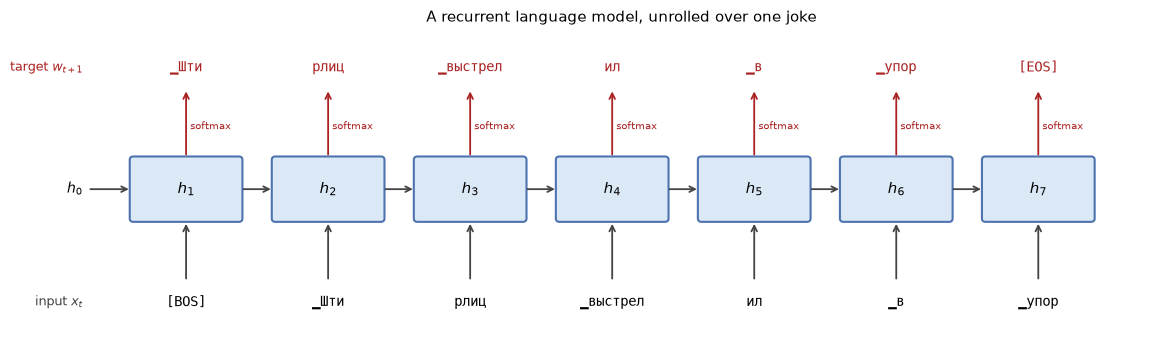

In [29]:
from matplotlib.patches import FancyBboxPatch


def draw_unrolled_lm(tokens, title="A recurrent language model, unrolled over one joke"):
    T = len(tokens) - 1
    fig, ax = plt.subplots(figsize=(1.55 * T + 1, 3.6)); ax.axis("off")
    ax.set_xlim(-0.6, 1.55 * T + 0.4); ax.set_ylim(-0.2, 3.5)
    arrow = dict(arrowstyle="->", color="#444", lw=1.3)
    for t in range(T):
        x = 1.55 * t
        ax.add_patch(FancyBboxPatch((x, 1.25), 1.15, 0.7, boxstyle="round,pad=0.04", fc="#dbe9f6", ec="#4c72b0", lw=1.5))
        ax.text(x + 0.575, 1.6, f"$h_{{{t + 1}}}$", ha="center", va="center", fontsize=11)
        ax.text(x + 0.575, 0.25, tokens[t], ha="center", va="center", fontsize=10, family="monospace")
        ax.annotate("", xy=(x + 0.575, 1.22), xytext=(x + 0.575, 0.5), arrowprops=arrow)
        ax.text(x + 0.575, 3.05, tokens[t + 1], ha="center", va="center", fontsize=10, family="monospace", color="#a22")
        ax.annotate("", xy=(x + 0.575, 2.8), xytext=(x + 0.575, 1.98), arrowprops=dict(arrowstyle="->", color="#a22", lw=1.3))
        ax.text(x + 0.62, 2.35, "softmax", ha="left", va="center", fontsize=7, color="#a22")
        if t > 0:
            ax.annotate("", xy=(x - 0.02, 1.6), xytext=(x - 0.38, 1.6), arrowprops=arrow)
    ax.annotate("", xy=(-0.02, 1.6), xytext=(-0.5, 1.6), arrowprops=arrow)
    ax.text(-0.55, 1.6, "$h_0$", ha="right", va="center", fontsize=10)
    ax.text(-0.55, 0.25, "input $x_t$", ha="right", va="center", fontsize=9, color="#444")
    ax.text(-0.55, 3.05, "target $w_{t+1}$", ha="right", va="center", fontsize=9, color="#a22")
    ax.set_title(title, fontsize=11); plt.tight_layout(); plt.show()


draw_unrolled_lm(["[BOS]", "▁Шти", "рлиц", "▁выстрел", "ил", "▁в", "▁упор", "[EOS]"])

Every position is a classification problem with $|V| = 8\,000$ classes: given the state, predict the next piece. The input at step $t$ is the token $w_t$; the target is $w_{t+1}$. So the model's input sequence for training process is the joke with `[BOS]` in front, the target sequence is the same joke shifted left by one with `[EOS]` at the end, and the loss is the average cross-entropy over all positions — which, as we established, is $\log$ of the perplexity. And if you remember, what perplexity was, you'll recall that this **training minimises perplexity directly.**

## 3.1 The data pipeline, and the three things that always go wrong

Jokes have different lengths, and a tensor does not. So we pad every batch to its longest sequence with `[PAD]`, and then we have to make sure the padding is (a) never predicted as a target, (b) never counted in the perplexity. `ignore_index=PAD` in the loss handles both, *if* the padding id is the one you told it. Getting this wrong silently makes perplexity look better than it is — the model learns to predict `[PAD]` after `[EOS]` with near-certainty, which is easy and worthless.

In [30]:
def encode_corpus(tok, texts):
    # [BOS] tokens [EOS] for every text, as a list of LongTensors
    return [torch.tensor([BOS] + enc.ids + [EOS], dtype=torch.long) for enc in tok.encode_batch(texts)]


def lm_batches(seqs, batch_size, shuffle, device=device):
    order = np.random.permutation(len(seqs)) if shuffle else np.arange(len(seqs))
    for i in range(0, len(seqs), batch_size):
        chunk = [seqs[j] for j in order[i:i + batch_size]]
        x = pad_sequence([s[:-1] for s in chunk], batch_first=True, padding_value=PAD)   # inputs
        y = pad_sequence([s[1:] for s in chunk], batch_first=True, padding_value=PAD)    # targets: shifted by one
        yield x.to(device), y.to(device)


train_seqs = encode_corpus(tok, train)
val_seqs = encode_corpus(tok, val)
test_seqs = encode_corpus(tok, test)

x, y = next(lm_batches(train_seqs[:3], batch_size=3, shuffle=False))
print("x (inputs) :", x.shape); print("y (targets):", y.shape, "\n")
show = lambda row: [tok.id_to_token(i) for i in row.tolist()]
pd.DataFrame({"x": show(x[2][:12]), "y": show(y[2][:12])}).T

x (inputs) : torch.Size([3, 47])
y (targets): torch.Size([3, 47]) 



,0,1,2,3,4,5,6,7,8,9,10,11
x,[BOS],▁,-,▁Вчера,▁на,▁концер,те,▁Миха,ил,▁По,пла,вский
y,▁,-,▁Вчера,▁на,▁концер,те,▁Миха,ил,▁По,пла,вский,▁упал


## 3.2 The model

Three components that matter: an embedding, a recurrent cell, a linear layer that classifies to the vocabulary. The `cell` argument lets us swap the recurrence — plain `RNN` ($h_t = \tanh(W x_t + U h_{t-1})$), `LSTM` (Hochreiter & Schmidhuber 1997) or `GRU` (Cho et al. 2014) — with everything else held fixed. That is the comparison we want: same data, same size, same optimiser, one thing changed.

This class is copied verbatim from `precompute.py`, so the weights we load later match.

In [31]:
class RNNLM(nn.Module):
    '''Embedding -> recurrent cell -> linear over the vocabulary. cell in {rnn, lstm, gru}.'''

    def __init__(self, vocab_size, emb=256, hidden=256, cell="lstm", num_layers=1, dropout=0.0):
        super().__init__()
        self.cell = cell
        self.emb = nn.Embedding(vocab_size, emb, padding_idx=PAD)
        rnn_cls = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[cell]
        self.rnn = rnn_cls(emb, hidden, num_layers=num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.out = nn.Linear(hidden, vocab_size)

    def forward(self, x, state=None):
        e = self.drop(self.emb(x))          # (B, T, E)
        h, state = self.rnn(e, state)       # (B, T, H)
        return self.out(self.drop(h)), state  # (B, T, V)


@torch.no_grad()
def lm_evaluate(model, seqs, texts, batch_size=256):
    '''Returns (perplexity per token, bits per character) — the same two numbers as for the n-grams.
    `texts` are the raw strings behind `seqs`: the character count is what makes bits/char tokenizer-independent.'''
    model.eval()
    nll, n_tok = 0.0, 0
    for x, y in lm_batches(seqs, batch_size, shuffle=False):
        logits, _ = model(x)
        nll += nn.functional.cross_entropy(logits.reshape(-1, V), y.reshape(-1), ignore_index=PAD, reduction="sum").item()
        n_tok += (y != PAD).sum().item()
    return math.exp(nll / n_tok), nll / sum(len(t) for t in texts) / math.log(2)


def train_lm(model, train_seqs, val_seqs, epochs, lr=2e-3, batch_size=128, clip=1.0):
    from tqdm.auto import tqdm
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    history = []
    for ep in range(1, epochs + 1):
        model.train()
        tot, n = 0.0, 0
        for x, y in tqdm(lm_batches(train_seqs, batch_size, shuffle=True), total=math.ceil(len(train_seqs) / batch_size), leave=False):
            logits, _ = model(x)
            loss = nn.functional.cross_entropy(logits.reshape(-1, V), y.reshape(-1), ignore_index=PAD)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)   # more on this in 3.4
            opt.step()
            k = (y != PAD).sum().item(); tot += loss.item() * k; n += k
        val_ppl, _ = lm_evaluate(model, val_seqs, val)
        history.append({"epoch": ep, "train_ppl": math.exp(tot / n), "val_ppl": val_ppl})
        print(f"epoch {ep}: train ppl {math.exp(tot / n):7.1f}   val ppl {val_ppl:7.1f}")
    return pd.DataFrame(history)

For the sake of demo, we'll train an LSTM on a slice of the data — enough to watch the perplexity move, small enough to finish while we talk.

Also, make a guess: after two epochs on 8 000 jokes, does this beat the interpolated trigram trained on all 117 000?

In [32]:
LIVE_JOKES, LIVE_EPOCHS = 8_000, 2

seed_all()
lm_live = RNNLM(V, emb=256, hidden=256, cell="lstm").to(device)
print(f"parameters: {sum(p.numel() for p in lm_live.parameters()) / 1e6:.2f}M")

t = time.time()
hist_live = train_lm(lm_live, train_seqs[:LIVE_JOKES], val_seqs, epochs=LIVE_EPOCHS)
live_s = time.time() - t

ppl, bpc = lm_evaluate(lm_live, test_seqs, test)
record(f"LSTM, {LIVE_JOKES // 1000}k jokes x {LIVE_EPOCHS} ep (live)", "BPE 8k", ppl, bpc,
       params=f"{sum(p.numel() for p in lm_live.parameters()) / 1e6:.1f}M", train_s=live_s)
show_results()

parameters: 4.63M


  0%|          | 0/63 [00:00<?, ?it/s]

epoch 1: train ppl  1062.5   val ppl   641.6


  0%|          | 0/63 [00:00<?, ?it/s]

epoch 2: train ppl   526.4   val ppl   504.6


,model,tokens,test_ppl,bits/char,params,train_s,note
0,"3-gram, interpolated",words,3109.1,1.918,"622,154 counts",NaN,count-based
1,"3-gram, interpolated",BPE 8k,210.9,2.396,"865,574 counts",NaN,count-based
2,"LSTM, 8k jokes x 2 ep (live)",BPE 8k,492.8,2.776,4.6M,21.0,


It does not — with 7% of the data and two passes, the network is still behind counting on all of it. Worth remembering the next time someone shows you a neural model losing to a baseline: the question is always *how much data and how much compute each one got*.

Let's look at what it says anyway. Same procedure as for the n-gram: feed `[BOS]`, sample a token from the softmax, feed it back, repeat until `[EOS]`.

In [33]:
@torch.no_grad()
def sample_text(model, prompt="", max_len=60, seed=None):
    # Plain sampling from the model's distribution; block 4 replaces this with something better.
    model.eval()
    g = torch.Generator(device="cpu").manual_seed(seed) if seed is not None else None
    ids = [BOS] + tok.encode(prompt).ids
    x = torch.tensor([ids], device=device)
    logits, state = model(x)
    for _ in range(max_len):
        probs = torch.softmax(logits[0, -1], dim=-1).cpu()
        nxt = torch.multinomial(probs, 1, generator=g).item()
        if nxt == EOS:
            break
        ids.append(nxt)
        logits, state = model(torch.tensor([[nxt]], device=device), state)
    return tok.decode(ids[1:])


for s in range(3):
    print("•", sample_text(lm_live, seed=s), "\n")

• Пибай мозги обидеми!- Сто, чтобы ты рыба маствовать го рядом. 

• - Вы, если бы Путин, чтобы вам ктоствуларя без ты? Опять вы мало польная курить О плохо" И:- Я фотографи" как кто- акбяет сиськиная. Какойшки у меня?- Ачина укойл пойду опятьвать. 

• Отецпен, тот твоюл наительствоете у меняно рас оle. Одиншин т Ка любимыйрис нефленграятсялись?-че. 



That doesn't seem right...

## 3.3 RNN vs LSTM vs GRU, on the full data

Now, let's see what happen if we move it to the full training data. For comparison we have three slightly different types of cells, the same 256-dimensional size, the same jokes, the same number of epochs each (see the plot below for the exact figures: it was trained overnight on CPU, if you want to redraw the image, run `precompute.py` on your machine).

Make a guess: the LSTM has 4× the recurrent parameters of the plain RNN (though that is cheap next to the 8 000-way output layer). On short jokes, trained for a few epochs, how far apart do the three land in perplexity — 5%, or 50%?

trained on 12,000 jokes for 3 epochs, emb=256, hidden=256



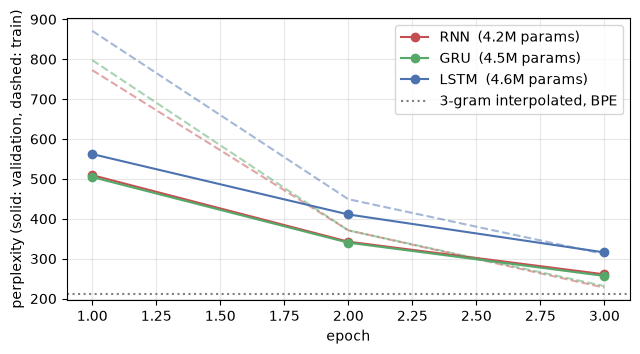

In [ ]:
if RECOMPUTE:
    !python precompute.py --data-dir data --out artifacts --only lm

with open(f"{ART_DIR}/lm_curves.json") as f:
    lm_curves = json.load(f)

cfg = lm_curves["lstm"]["config"]
print(f"trained on {cfg['n_train_jokes']:,} jokes for {cfg['epochs']} epochs, emb={cfg['emb']}, hidden={cfg['hidden']}\n")

plt.figure(figsize=(6.5, 3.6))
for cell, c in zip(["rnn", "gru", "lstm"], ["#c44e52", "#55a868", "#4c72b0"]):
    cv = lm_curves[cell]
    plt.plot(cv["epoch"], cv["val_ppl"], "o-", color=c, label=f"{cell.upper()}  ({cv['n_params'] / 1e6:.1f}M params)")
    plt.plot(cv["epoch"], cv["train_ppl"], "--", color=c, alpha=.5)
plt.axhline(results[1]["test_ppl"], color="gray", ls=":", label="3-gram interpolated, BPE")
plt.xlabel("epoch"); plt.ylabel("perplexity (solid: validation, dashed: train)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

In [35]:
lms = {}
for cell in ["rnn", "gru", "lstm"]:
    m = RNNLM(V, emb=256, hidden=256, cell=cell).to(device)
    m.load_state_dict(torch.load(f"{ART_DIR}/lm_{cell}.pt", map_location=device))
    m.eval()
    lms[cell] = m
    cv = lm_curves[cell]
    ppl, bpc = lm_evaluate(m, test_seqs, test)
    record(f"{cell.upper()}, {cfg['n_train_jokes'] // 1000}k jokes x {cfg['epochs']} ep", "BPE 8k", ppl, bpc,
           params=f"{cv['n_params'] / 1e6:.1f}M", train_s=cv["seconds"][-1], note="precomputed")

lm = lms["lstm"]   # the model for the rest of the notebook
show_results()

,model,tokens,test_ppl,bits/char,params,train_s,note
0,"3-gram, interpolated",words,3109.1,1.918,"622,154 counts",NaN,count-based
1,"3-gram, interpolated",BPE 8k,210.9,2.396,"865,574 counts",NaN,count-based
2,"LSTM, 8k jokes x 2 ep (live)",BPE 8k,492.8,2.776,4.6M,21.0,
3,"RNN, 12k jokes x 3 ep",BPE 8k,256.8,2.484,4.2M,123.0,precomputed
4,"GRU, 12k jokes x 3 ep",BPE 8k,252.3,2.476,4.5M,139.0,precomputed
5,"LSTM, 12k jokes x 3 ep",BPE 8k,309.5,2.567,4.6M,144.0,precomputed


In [39]:
for s in range(3):
    print("•", sample_text(lm, seed=s), "\n")

• Пибайнцияминый Ржевский, вере Ко время рыба маствовать го ФСБ. 

• Боль алжны - это четвервшего болезвания, а туда без ты? Опять вы мало на глаза курить Оке" Ивой. 

• Отец папа, отлично твоюл на лестете ущаютсяно рассть... С тский любимыйрис-то запятся акжилужиче. 



Three readings, and the big one is not the one the textbook promises:

* **The neural models do not beat the count baseline here.** Compare the BPE rows, same tokenizer and test set, so `test_ppl` and `bits/char` are both fair: the interpolated **BPE trigram** sits *below* our small RNNs in perplexity. A well-smoothed count model, trained on all the jokes in seconds, is not a weak opponent — and a 4.6M-parameter network trained for three epochs on a slice of the data does not clear it. This is the same result as last week's "averaged embeddings lose to TF-IDF", and the same lesson: **run the strong simple baseline first**, because the sophisticated thing has to earn its cost, and at this scale it has not yet. The neural win is real, but it arrives with *scale* — more data, more epochs, more parameters — and we are deliberately under all three so the notebook runs on a laptop. (Retrain on all ~117k jokes for more epochs, via `precompute.py` without the CPU flags, and the network pulls clearly ahead.)
* **Among the neural models the three are close** — within ~20% — and the plain RNN keeps up with the gated cells. The LSTM's advantage is about carrying information across *long* distances; our jokes are short (median ~30 BPE tokens) and the dependencies that pick the next subword are mostly local, so there is little for a gate to save. GRU and LSTM land in the same place as usual (Chung et al. 2014; Greff et al. 2017). Change the corpus to something with long-range structure and the gap opens; the method did not change, the demand on memory did.

So why bother with the network at all, if a trigram matches it? Two reasons the table cannot show, and one it can:

* **It generalises instead of memorising.** Recall block 2.1: the 5-gram *recited* the training set (that copied-verbatim number). The RNN, if not extremely overfitted, at similar perplexity, writes text that is not in the corpus — it learned a distribution, not a lookup table. Same perplexity, completely different behaviour, and the difference is the whole point.
* **It scales, and counting does not.** The trigram is already at its ceiling on 2M words; the sparsity plot showed why. The network's curve is still falling at epoch 3. One of these has somewhere to go.

The next section measures the mechanism that makes the difference — and shows why the plain RNN, which keeps up on short jokes, is living on borrowed time.

(The train/validation gap is worth a glance too: the dashed lines keep falling while the solid ones flatten — a few epochs on this much data is about where this size of model starts to memorise. More epochs would want dropout; see the 🏠 at the end of the block.)

## 3.4 Why the plain RNN loses: gradients through time

To learn that the beginning of a joke matters for its end, the gradient of the loss at the last token has to travel back through every step of the recurrence to the first token. Each step multiplies it by the Jacobian $\partial h_{t} / \partial h_{t-1}$. Thirty steps, thirty multiplications: if the typical factor is below one the gradient vanishes, if above one it explodes (Bengio et al. 1994; Pascanu et al. 2013). A plain $\tanh$ recurrence does both, depending on the weights.

The LSTM's cell state has a path through time that is *additive* — $c_t = f_t \odot c_{t-1} + i_t \odot \tilde c_t$ — so the gradient can pass through the forget gate unchanged instead of being multiplied by a weight matrix at every step. That is the whole trick, and it is measurable.

We take a joke, compute the loss **at the last position only**, and ask how large its gradient is with respect to the input embedding at each earlier position. In a model that remembers, the early positions still get a signal.

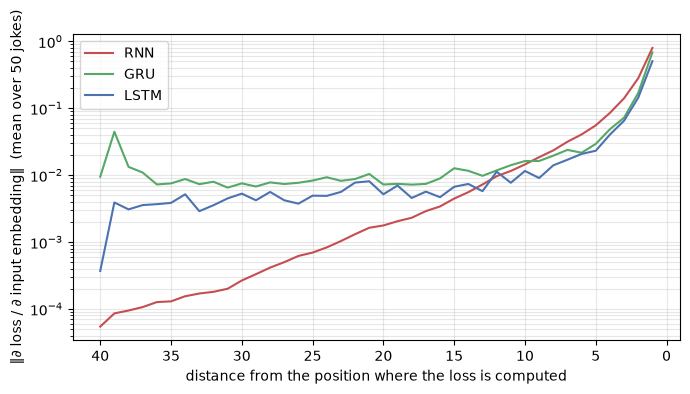

In [36]:
def gradient_through_time(model, seq):
    model.eval()
    x = seq[:-1].unsqueeze(0).to(device)
    e = model.emb(x); e.retain_grad()
    h, _ = model.rnn(e)
    loss = nn.functional.cross_entropy(model.out(h)[0, -1:], seq[-1:].to(device))
    model.zero_grad(); loss.backward()
    return e.grad[0].norm(dim=-1).cpu().numpy()          # one number per input position


L = 40
long_jokes = [s[:L + 1] for s in test_seqs if len(s) > L + 1][:50]

plt.figure(figsize=(7, 3.8))
for cell, c in zip(["rnn", "gru", "lstm"], ["#c44e52", "#55a868", "#4c72b0"]):
    g = np.mean([gradient_through_time(lms[cell], s) for s in long_jokes], axis=0)
    plt.semilogy(np.arange(L, 0, -1), g, color=c, label=cell.upper())
plt.xlabel("distance from the position where the loss is computed"); plt.ylabel("‖∂ loss / ∂ input embedding‖  (mean over 50 jokes)")
plt.gca().invert_xaxis(); plt.legend(); plt.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()

The plain RNN's gradient drops by orders of magnitude within a dozen steps: whatever happened at the start of the joke, the loss at the end cannot teach the model anything about it. The LSTM and GRU decay far more slowly. This is the mechanism, and it is the answer to the puzzle in 3.3: on *short* jokes almost nothing depends on a token 30 steps back, so the RNN's blindness there costs it little perplexity — but the blindness is real, and the moment the task needs long-range memory (a longer text, a matching bracket, an agreement across a clause) the RNN cannot learn it *at all*, while the LSTM still can. The close perplexities did not mean the cells are equivalent; they meant this corpus did not test the thing the cells differ on.

There is a second failure mode, and it is the reason for the one line in `train_lm` we skipped over. Here is the norm of the gradient at every 20th training step, *before* clipping:

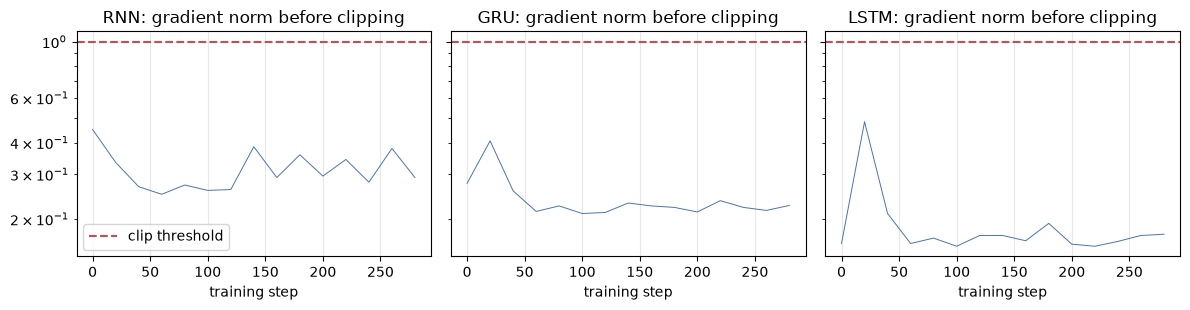

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, cell in zip(axes, ["rnn", "gru", "lstm"]):
    g = np.array(lm_curves[cell]["grad_norms"])
    ax.plot(np.arange(len(g)) * 20, g, lw=.7, color="#4c72b0")
    ax.axhline(1.0, color="#c44e52", ls="--", label="clip threshold")
    ax.set_yscale("log"); ax.set_title(f"{cell.upper()}: gradient norm before clipping"); ax.set_xlabel("training step"); ax.grid(alpha=.3)
axes[0].legend(); plt.tight_layout(); plt.show()

Spikes. The occasional batch produces a gradient ten or a hundred times larger than usual — one exploding path through the recurrence — and a single such step at learning rate $2 \cdot 10^{-3}$ can wreck the weights. **Gradient clipping** (`clip_grad_norm_`) rescales any gradient above a threshold to that threshold. It costs nothing, it is in every recurrent training loop since Pascanu et al. (2013), and it is one of the few tricks from the RNN era that survived into transformer training unchanged.

Open question 3: the LSTM was designed in 1997 to fix vanishing gradients, and the plot above shows it does. Yet it also plateaus, and its gradient at 40 steps is not the same as at 1. What is the remaining limit — the arithmetic, or the 256 numbers of the state vector? How would you tell the two apart?

### 🏠 Homework: three parameters worth playing with

Everything here runs as written; nothing is needed for the rest of the seminar. Change `RUN_HOMEWORK` to `True`.

* **Weight tying** (Press & Wolf 2017; Inan et al. 2017). The input embedding and the output layer are both $|V| \times d$ matrices that map tokens to vectors. Make them *the same matrix*: it removes 2M parameters (a third of this model) and usually *improves* perplexity. Requires `emb == hidden`.
* **Dropout.** The train/val gap in 3.3 was opening. Dropout on the embeddings and on the recurrent output is the standard fix (Zaremba et al. 2014); with it, ten epochs beat five.
* **Depth.** `num_layers=2`. On this much data, does a second layer pay for itself?

In [38]:
RUN_HOMEWORK = False

class TiedRNNLM(RNNLM):
    def __init__(self, vocab_size, emb=256, hidden=256, cell="lstm", num_layers=1, dropout=0.0):
        assert emb == hidden, "tying needs the embedding and the hidden size to match"
        super().__init__(vocab_size, emb, hidden, cell, num_layers, dropout)
        self.out.weight = self.emb.weight     # one matrix, two jobs

if RUN_HOMEWORK:
    for name, m in [("LSTM (baseline)", RNNLM(V, cell="lstm")),
                    ("LSTM, tied", TiedRNNLM(V, cell="lstm")),
                    ("LSTM, tied, dropout 0.3", TiedRNNLM(V, cell="lstm", dropout=0.3)),
                    ("LSTM, tied, 2 layers, dropout 0.3", TiedRNNLM(V, cell="lstm", num_layers=2, dropout=0.3))]:
        seed_all(); m = m.to(device)
        t = time.time(); train_lm(m, train_seqs[:20_000], val_seqs, epochs=4)
        ppl, bpc = lm_evaluate(m, test_seqs, test)
        record(name + ", 20k x 4 ep", "BPE 8k", ppl, bpc, params=f"{sum(p.numel() for p in m.parameters()) / 1e6:.1f}M", train_s=time.time() - t, note="homework")
    display(show_results())

# 4. The decoding rule: turning a distribution into text

We have a model that, given a prefix, returns a distribution over 8 000 next tokens. We have been sampling from it, but that was one choice among many, and it turns out to be the choice that matters most for how the text reads. This is the right factor of the seminar's opening equation, and for the whole RNN era it was an afterthought. Holtzman et al. (2019) is the paper that made the field take it seriously; this block is that paper, reproduced on our own model.

Everything below operates on a single vector of **logits** — the model's output before the softmax — for one position. Each method is a small function that turns that vector into a chosen token id. Whatever the model, the interface is the same, which is exactly why the code that generates from a 6M-parameter LSTM is byte-for-byte the code that drives a 400B-parameter LLM.

In [40]:
@torch.no_grad()
def next_logits(model, ids):
    # the model's logits for the token after `ids`
    x = torch.tensor([ids], device=device)
    logits, _ = model(x)
    return logits[0, -1].cpu()


@torch.no_grad()
def generate(model, decode_step, prompt="", max_len=60, seed=None):
    '''
    Autoregressive loop. `decode_step(logits, generator) -> token_id` is the ONLY thing that changes
    between decoding methods. Everything else — feed prompt, loop, stop on [EOS] — is fixed.
    '''
    g = torch.Generator().manual_seed(seed) if seed is not None else None
    ids = [BOS] + tok.encode(prompt).ids
    state = None
    x = torch.tensor([ids], device=device)
    logits, state = model(x)
    for _ in range(max_len):
        nxt = decode_step(logits[0, -1].cpu(), g)
        if nxt == EOS:
            break
        ids.append(nxt)
        logits, state = model(torch.tensor([[nxt]], device=device), state)
    return tok.decode(ids[1:])

## 4.1 The two extremes: greedy and pure sampling

The two obvious rules sit at opposite ends. **Greedy** takes the single most probable token every time — deterministic, and it maximises the probability of each *step*. **Pure sampling** draws from the distribution as the model gives it — every token with exactly the probability the model assigned.

Make a guess: one of these produces repetitive, looping text; the other produces incoherent, drifting text. Which is which?

In [41]:
def greedy_step(logits, g=None):
    return int(logits.argmax())


def sample_step(logits, g=None):
    probs = torch.softmax(logits, dim=-1)
    return int(torch.multinomial(probs, 1, generator=g))


print("GREEDY (argmax every step):\n")
for s in range(2):
    print("•", generate(lm, greedy_step, seed=s), "\n")

print("\nPURE SAMPLING (from the raw distribution):\n")
for s in range(3):
    print("•", generate(lm, sample_step, seed=s), "\n")

GREEDY (argmax every step):

• - Я не могу, что у меня есть?- Да, а я не могу, что у меня есть?- Да, а я не могу, что у меня есть?- Да, а я не могу. 

• - Я не могу, что у меня есть?- Да, а я не могу, что у меня есть?- Да, а я не могу, что у меня есть?- Да, а я не могу. 


PURE SAMPLING (from the raw distribution):

• Пибайнцияминый Ржевский, вере Ко время рыба маствовать го ФСБ. 

• Боль алжны - это четвервшего болезвания, а туда без ты? Опять вы мало на глаза курить Оке" Ивой. 

• Отец папа, отлично твоюл на лестете ущаютсяно рассть... С тский любимыйрис-то запятся акжилужиче. 



Greedy loops — and greedy is *deterministic*, so it produces the same text regardless of the seed, and once it enters a loop it cannot leave. This is Holtzman's central, counter-intuitive result: the most probable continuation is a *worse* continuation than a random one. Maximising probability at every step walks you into the high-probability, low-information regions of the language — the phrases that are safe everywhere and mean nothing.

Pure sampling does not loop, but it drifts: the model puts a small probability on thousands of tokens, and the *sum* of that tail is large, so at almost every step there is a real chance of drawing something the model thought was unlikely. One unlucky token and the prefix is now nonsense, which makes the next token worse. Both failures are real, and every method below is an attempt to sit between them.

## 4.2 Temperature: one dial over the whole distribution

Before touching *which* tokens, we can reshape *how peaked* the distribution is. Divide the logits by a temperature $T$ before the softmax:

$$P_i = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

$T = 1$ is the model's own distribution. $T \to 0$ concentrates all mass on the argmax — temperature-zero sampling *is* greedy. $T > 1$ flattens toward uniform, raising the chance of rare tokens. It changes nothing about the model; it is a parameter on the sampler.

Let us see it on one real distribution — the model's prediction after a short prompt — at several temperatures, with the entropy (the perplexity of that single step) underneath.

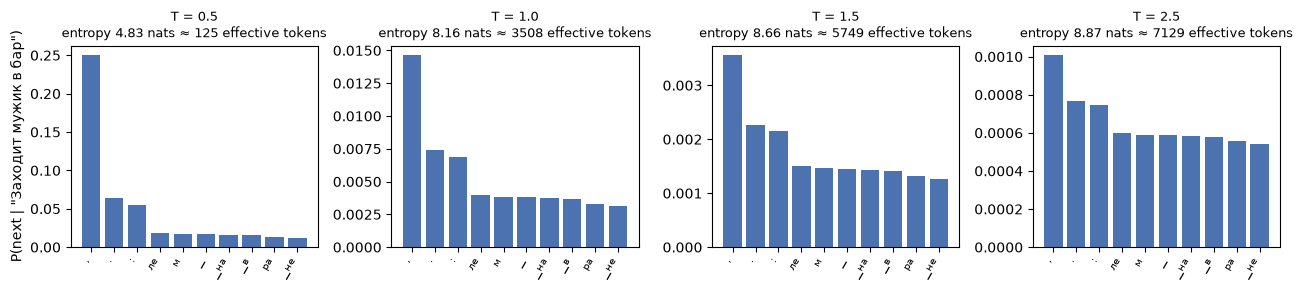

In [42]:
def softmax_T(logits, T):
    return torch.softmax(logits / T, dim=-1)


prompt = "Заходит мужик в бар"
logits0 = next_logits(lm, [BOS] + tok.encode(prompt).ids)

fig, axes = plt.subplots(1, 4, figsize=(13, 3), sharey=False)
for ax, T in zip(axes, [0.5, 1.0, 1.5, 2.5]):
    p = softmax_T(logits0, T)
    topp, topi = p.topk(10)
    ax.bar(range(10), topp.numpy(), color="#4c72b0")
    ax.set_xticks(range(10)); ax.set_xticklabels([tok.id_to_token(i) for i in topi.tolist()], rotation=60, ha="right", fontsize=7)
    H = -(p * torch.clamp(p, min=1e-12).log()).sum().item()
    ax.set_title(f"T = {T}\nentropy {H:.2f} nats ≈ {math.exp(H):.0f} effective tokens", fontsize=9)
axes[0].set_ylabel(f'P(next | "{prompt}")')
plt.tight_layout(); plt.show()

In [43]:
def temperature_step(T):
    def step(logits, g=None):
        return int(torch.multinomial(softmax_T(logits, T), 1, generator=g))
    return step


for T in [0.3, 0.7, 1.0, 1.5]:
    print(f"T = {T}:")
    print("  •", generate(lm, temperature_step(T), prompt=prompt, seed=0), "\n")

T = 0.3:
  • Заходит мужик в бар, а у вас в России. 

T = 0.7:
  • Заходит мужик в баррисувают поми! 

T = 1.0:
  • Заходит мужик в бар закасувают вами! 

T = 1.5:
  • Заходит мужик в бар закабай Уже обидепой! Ржевский пациент вере Ко время рыба маствовать го ФСБтурерулись.Агает как я российскийсать луч своей вижубой.. Долгогна способ просят заскида буди брюнет тему: двумя своимидомнеот никак Г цебав море. какойвенныепти си мужчины 



Low temperature is safe and repetitive; it approaches greedy. High temperature is adventurous and, past a point, incoherent — at $T = 1.5$ the tail is thick enough to derail the joke. There is no correct value; there is a value that suits the task. Code completion wants $T$ near 0; brainstorming wants it near 1. The default in most APIs is 0.7–1.0.

But temperature is a blunt instrument: it rescales *the whole distribution*. It cannot say "keep the sensible options and delete the absurd ones", because raising $T$ to explore the sensible middle *also* fattens the absurd tail. The next two methods truncate instead of rescaling.

## 4.3 Truncation: top-k and top-p (nucleus)

The insight is that the tail of the distribution — the thousands of tokens with tiny probability — is where the incoherence comes from, and it should simply be cut off before sampling.

**Top-k** (Fan et al. 2018): keep the $k$ most probable tokens, zero the rest, renormalise, sample. Simple, but $k$ is a fixed count and the distribution is not a fixed shape: after "Заходит мужик в" a handful of tokens are plausible, but after a comma almost anything is. A fixed $k$ is too restrictive in the first case and too permissive in the second.

**Top-p / nucleus** (Holtzman et al. 2019): keep the smallest set of tokens whose probability *sums* to $p$ (say 0.9), zero the rest, renormalise, sample. The size of the kept set now adapts — 3 tokens when the model is confident, 200 when it is not. This is the method that made sampling the default for open-ended generation, and it is still the standard.

A picture of what each one keeps, on a confident step and an uncertain one:

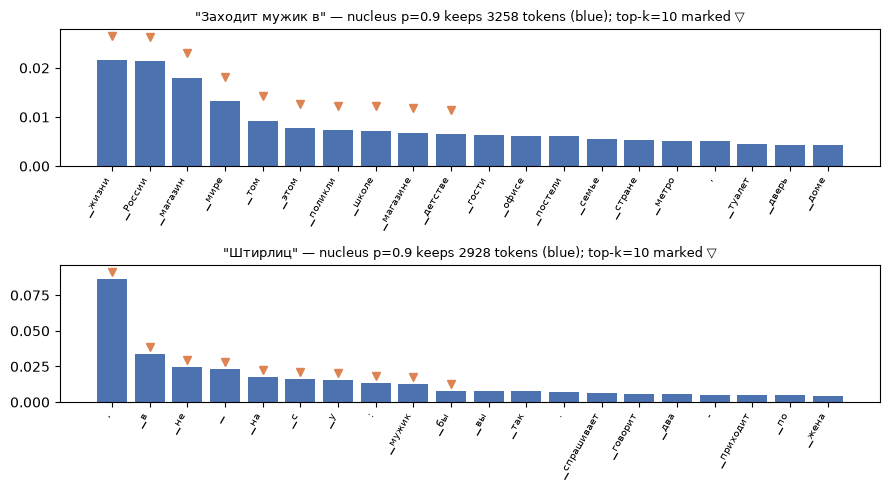

In [44]:
def masked(logits, keep_idx):
    p = torch.softmax(logits, dim=-1)
    m = torch.zeros_like(p); m[keep_idx] = p[keep_idx]
    return m / m.sum()

def topk_keep(logits, k):
    return logits.topk(k).indices

def topp_keep(logits, p):
    sp, si = torch.softmax(logits, dim=-1).sort(descending=True)
    cutoff = int((sp.cumsum(0) < p).sum()) + 1
    return si[:cutoff]

prompts = ["Заходит мужик в", "Штирлиц"]
fig, axes = plt.subplots(2, 1, figsize=(9, 5))
for ax, pr in zip(axes, prompts):
    lg = next_logits(lm, [BOS] + tok.encode(pr).ids)
    p = torch.softmax(lg, dim=-1)
    topp_, topi = p.topk(20)
    k_set = set(topk_keep(lg, 10).tolist())
    p_set = set(topp_keep(lg, 0.9).tolist())
    colors = ["#4c72b0" if i in p_set else "#c7c7c7" for i in topi.tolist()]
    ax.bar(range(20), topp_.numpy(), color=colors)
    for j, i in enumerate(topi.tolist()):
        if i in k_set:
            ax.plot(j, topp_[j] + 0.005, "v", color="#dd8452", ms=6)
    ax.set_xticks(range(20)); ax.set_xticklabels([tok.id_to_token(i) for i in topi.tolist()], rotation=60, ha="right", fontsize=7)
    ax.set_title(f'"{pr}" — nucleus p=0.9 keeps {len(p_set)} tokens (blue); top-k=10 marked ▽', fontsize=9)
plt.tight_layout(); plt.show()

On the confident prompt, nucleus keeps only a few tokens — top-k=10 is already reaching into noise. On the uncertain one, nucleus opens up. Top-k keeps ten either way. That adaptivity is the whole argument for top-p.

There is a newer, even simpler idea, **min-p** (Nguyen et al. 2024): keep every token whose probability is at least $p_{\min}$ times the probability of the *most likely* token. When the top token has 0.9, the bar is high and little survives; when the top token has 0.05, the bar is low and many do. It adapts like nucleus but with one multiply, and it holds up better at high temperature. All three are one function:

In [45]:
def truncated_step(method, value, T=1.0):
    def step(logits, g=None):
        logits = logits / T
        p = torch.softmax(logits, dim=-1)
        if method == "top_k":
            keep = p.topk(value).indices
        elif method == "top_p":
            sp, si = p.sort(descending=True)
            keep = si[:int((sp.cumsum(0) < value).sum()) + 1]
        elif method == "min_p":
            keep = (p >= value * p.max()).nonzero().squeeze(-1)
        m = torch.zeros_like(p); m[keep] = p[keep]
        return int(torch.multinomial(m / m.sum(), 1, generator=g))
    return step


for name, step in [("top-k = 40", truncated_step("top_k", 40)),
                   ("top-p = 0.9", truncated_step("top_p", 0.9)),
                   ("min-p = 0.05", truncated_step("min_p", 0.05)),
                   ("top-p = 0.9, T = 0.8", truncated_step("top_p", 0.9, T=0.8))]:
    print(f"{name}:")
    print("  •", generate(lm, step, prompt="Заходит мужик в бар", seed=1), "\n")

top-k = 40:
  • Заходит мужик в бар, вы бы, он бы на его только, кто я хочу. 

top-p = 0.9:
  • Заходит мужик в бар 3сь снына бы Путин, чтобы вам кто возьла туда без хватает?- Да. Наная курить! 

min-p = 0.05:
  • Заходит мужик в бар, вы бы о чем бы будет, чтобы они несмотря, как я не хочет, вы знаете, вы вас не могу, что я с ним "А надо это же на?- О... 

top-p = 0.9, T = 0.8:
  • Заходит мужик в бар 3ражны - это когда хочется вам не изобрелила. 



## 4.4 The picture that named the problem

Here is the plot from Holtzman et al. that reframed the field. Take a real joke from the test set and, at every position, ask the model: *what probability did you assign to the token that actually came next?* Do the same for the model's own greedy ("beam-like") continuation. Then look at the two curves.

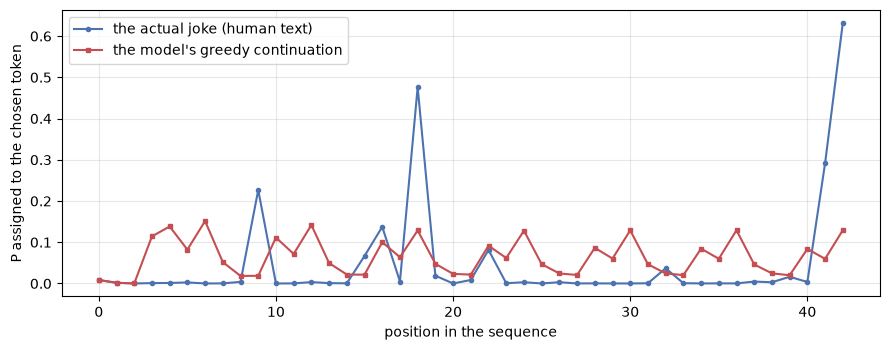

In [46]:
@torch.no_grad()
def token_probs_of(model, ids):
    # P(token_t | prefix) that the model assigns to each actual token in `ids`
    x = torch.tensor([ids[:-1]], device=device)
    logits, _ = model(x)
    p = torch.softmax(logits[0], dim=-1)
    return [p[t, ids[t + 1]].item() for t in range(len(ids) - 1)]


@torch.no_grad()
def greedy_ids(model, prompt_ids, n):
    ids, state = list(prompt_ids), None
    logits, state = model(torch.tensor([ids], device=device))
    for _ in range(n):
        nxt = int(logits[0, -1].argmax())
        ids.append(nxt)
        logits, state = model(torch.tensor([[nxt]], device=device), state)
    return ids


real = test_seqs[7].tolist()
p_human = token_probs_of(lm, real)
g_ids = greedy_ids(lm, real[:4], len(real) - 4)
p_greedy = token_probs_of(lm, g_ids)

plt.figure(figsize=(9, 3.6))
plt.plot(p_human, "o-", ms=3, color="#4c72b0", label="the actual joke (human text)")
plt.plot(p_greedy, "s-", ms=3, color="#c44e52", label="the model's greedy continuation")
plt.xlabel("position in the sequence"); plt.ylabel("P assigned to the chosen token")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

The human text is **jagged**: real language constantly includes tokens the model found unlikely — a surprising word is what makes a sentence worth reading. The greedy continuation is a **flat line near 1.0**: it only ever emits tokens it was already sure of, which is precisely why it reads as bland and loops. "Natural language does not maximise probability" is the one-sentence version, and the fix is not a better model — it is a decoding rule that reintroduces the jaggedness on purpose. That is what sampling with truncation does.

We can turn "jaggedness" into two numbers and measure every method at once:

* **repetition** — the fraction of generated tokens that repeat a token from within the last 20. Greedy's loops send this high.
* **distinct-2** — the fraction of generated bigrams that are unique. Diversity; pure sampling sends this high, sometimes too high.

In [47]:
def repetition_rate(ids, window=20):
    rep = sum(ids[i] in ids[max(0, i - window):i] for i in range(len(ids)))
    return rep / max(1, len(ids))

def distinct2(ids):
    bg = list(zip(ids, ids[1:]))
    return len(set(bg)) / max(1, len(bg))


methods = {
    "greedy": greedy_step,
    "sampling T=1.0": temperature_step(1.0),
    "sampling T=0.7": temperature_step(0.7),
    "top-k=40": truncated_step("top_k", 40),
    "top-p=0.9": truncated_step("top_p", 0.9),
    "min-p=0.05": truncated_step("min_p", 0.05),
}
rows = []
prompts_eval = ["Заходит мужик", "Штирлиц", "Приходит муж домой", "Однажды", "Доктор говорит"]
for name, step in methods.items():
    reps, d2, lp = [], [], []
    for pr in prompts_eval:
        for s in range(6):
            ids = [BOS] + tok.encode(generate(lm, step, prompt=pr, seed=s)).ids
            reps.append(repetition_rate(ids)); d2.append(distinct2(ids))
            lp.append(np.mean([math.log(max(1e-9, p)) for p in token_probs_of(lm, ids)]))
    rows.append({"method": name, "repetition": np.mean(reps), "distinct-2": np.mean(d2),
                 "avg logprob/token": np.mean(lp)})
decode_table = pd.DataFrame(rows)
decode_table.style.format({"repetition": "{:.1%}", "distinct-2": "{:.1%}", "avg logprob/token": "{:.2f}"})

,method,repetition,distinct-2,avg logprob/token
0,greedy,77.1%,24.6%,-2.78
1,sampling T=1.0,6.9%,98.7%,-6.18
2,sampling T=0.7,12.4%,97.2%,-4.44
3,top-k=40,12.4%,97.8%,-4.00
4,top-p=0.9,7.0%,99.0%,-5.85
5,min-p=0.05,11.9%,97.4%,-4.29


Look at the `avg logprob/token` column against the other two. Greedy has the **highest** average log-probability — by construction, it is the most probable text — and the **worst** repetition. The sampling methods give up log-probability and buy back diversity. This is the likelihood trap made quantitative: the objective the model was *trained* on (probability) is not the objective you *decode* for (readable text), and optimising the first too hard destroys the second.

**Open question 4:** distinct-2 keeps rising as you sample more aggressively, but past some point the text is nonsense. So higher distinct-2 is not simply better. Human text has a *particular* value of these statistics — not the maximum. How would you turn "reads like a human wrote it" into a target for the sampler? (This is roughly what Holtzman's *perplexity-matching* argument does.)

## 4.5 Repetition penalty — patching the symptom

Since repetition is the visible failure, the most-used industrial patch attacks it directly: **repetition penalty** (Keskar et al. 2019) divides the logit of any token that already appeared by a factor > 1 before sampling; **no-repeat-n-gram** (from beam-search MT) hard-bans any token that would complete an $n$-gram already generated. Both are hacks — they fight a symptom of maximisation rather than its cause — but they are cheap and they work, and every serious generation API exposes them.

In [48]:
def penalised_step(base_step, penalty=1.3, no_repeat_ngram=3):
    history = []
    def step(logits, g=None):
        logits = logits.clone()
        for t in set(history):                              # repetition penalty
            logits[t] /= penalty if logits[t] > 0 else 1 / penalty
        if no_repeat_ngram and len(history) >= no_repeat_ngram - 1:
            prefix = tuple(history[-(no_repeat_ngram - 1):])  # ban tokens that complete a seen n-gram
            for i in range(len(history) - no_repeat_ngram + 1):
                if tuple(history[i:i + no_repeat_ngram - 1]) == prefix:
                    logits[history[i + no_repeat_ngram - 1]] = -float("inf")
        nxt = base_step(logits, g)
        history.append(nxt)
        return nxt
    return step


print("greedy, unpatched — loops:")
print("  •", generate(lm, greedy_step, prompt="Однажды", seed=0), "\n")
print("greedy + repetition penalty 1.3 + no-repeat-3gram:")
print("  •", generate(lm, penalised_step(greedy_step, 1.3, 3), prompt="Однажды", seed=0))

greedy, unpatched — loops:
  • Однажды, что у меня есть?- Да, что у меня есть?- Да, а я не могу, что у меня есть?- Да, а я не могу, что у меня есть?- Да, а я не могу. 

greedy + repetition penalty 1.3 + no-repeat-3gram:
  • Однажды, что у меня есть?- Да.


## 4.6 Beam search — and why it is *not* here for jokes

Everything so far picks one token and moves on. **Beam search** keeps the $b$ most probable *sequences* at every step, expanding all of them and pruning back to $b$, so it can recover from a locally bad token that leads somewhere globally good. It approximates $\arg\max_{\text{sequence}} P(\text{sequence})$ far better than greedy.

For **open-ended generation this is the wrong goal** — we just spent five sections showing that the most probable text is the blandest — so beam search on our joke model produces the most generic, loop-prone output of all. That is why the toolbox above is all sampling.

Beam search comes back into its own the moment there is a *right answer* to approximate: translation, summarisation, speech recognition — tasks where the output is largely determined by the input and you genuinely want the highest-probability sequence. So we defer the implementation to the next block, where we have a translation model to run it on, and there it will earn its place.

## 4.7 The same rules, on a real LLM

Nothing above was specific to our LSTM. To prove it, the exact same `decode_step` functions drive a small pretrained GPT-2 — *if* you are online and want to install `transformers`. The point to see: `top_p`, `temperature`, `repetition_penalty` are the identical parameters, because HuggingFace's `generate` is doing exactly what block 4 did — its `LogitsProcessor` classes *are* our `decode_step` functions.

In [51]:
RUN_LLM = True   # set True with internet + `pip install transformers`; downloads ~500 MB

if RUN_LLM:
    from transformers import AutoModelForCausalLM, AutoTokenizer
    name = "sberbank-ai/rugpt3small_based_on_gpt2"
    gpt_tok = AutoTokenizer.from_pretrained(name)
    gpt = AutoModelForCausalLM.from_pretrained(name).to(device).eval()

    inp = gpt_tok("Заходит мужик в бар", return_tensors="pt").to(device)
    for tag, kw in [("greedy", dict(do_sample=False)),
                    ("top-p=0.9, T=0.9", dict(do_sample=True, top_p=0.9, temperature=0.9)),
                    ("top-p=0.9 + rep.penalty 1.3", dict(do_sample=True, top_p=0.9, repetition_penalty=1.3))]:
        out = gpt.generate(**inp, max_new_tokens=40, pad_token_id=gpt_tok.eos_token_id, **kw)
        print(f"{tag}:\n  {gpt_tok.decode(out[0], skip_special_tokens=True)}\n")
else:
    print("RUN_LLM is False — the LSTM demos above already show every method. Flip it to see the same knobs on GPT-2.")

config.json:   0%|          | 0.00/720 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.25k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.71M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.27M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/574 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  551MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: sberbank-ai/rugpt3small_based_on_gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


greedy:
  Заходит мужик в бар, а там сидит мужик и говорит:

— Ну, что, мужики, за работу?

— За работу, — отвечают мужики.

— А что,

top-p=0.9, T=0.9:
  Заходит мужик в бар, подходит к одному из пьющих посетителей и говорит:
- Ну, что там?
- Загар на работе.
- Вы чего?
- А ничего.
- Чего-то

top-p=0.9 + rep.penalty 1.3:
  Заходит мужик в бар. Открыл дверь и зашел внутрь, а за ним выходит женщина — на вид ей лет пятьдесят пяти с небольшим! — одетая как-то не так: брюки до колен черные сапоги… На



### 🎛️ Optional: interactive sampler (needs `ipywidgets`)

Drag the sliders in class to feel how temperature, top-k and top-p trade coherence for diversity on the same prompt.

In [53]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    def _demo(prompt="Заходит мужик в бар", T=0.9, top_p=0.9, top_k=0, seed=0):
        step = truncated_step("top_k", top_k, T) if top_k > 0 else truncated_step("top_p", top_p, T)
        print(generate(lm, step, prompt=prompt, seed=seed))

    widgets.interact(_demo,
                     prompt=widgets.Text("Заходит мужик в бар"),
                     T=widgets.FloatSlider(value=0.9, min=0.1, max=2.0, step=0.1),
                     top_p=widgets.FloatSlider(value=0.9, min=0.1, max=1.0, step=0.05),
                     top_k=widgets.IntSlider(value=0, min=0, max=200, step=10),
                     seed=widgets.IntSlider(value=0, min=0, max=20))
except Exception as e:
    print("ipywidgets not available — skip.", e)

interactive(children=(Text(value='Заходит мужик в бар', description='prompt'), FloatSlider(value=0.9, descript…

# 5. Conditioning on another sequence: seq2seq

Everything so far generates text from nothing but a prefix. The moment you want to generate text *from an input* — translate a sentence, summarise a document, answer a question — you need one more idea: condition the language model on a second sequence.

The **encoder–decoder** (Sutskever et al. 2014; Cho et al. 2014) does it in the most direct way imaginable. One RNN — the **encoder** — reads the input and boils it down to a fixed-size vector. A second RNN — the **decoder** — is a language model exactly like block 3, except its initial state is that vector instead of zeros. So the decoder generates English, but it starts from a summary of the German. Same chain rule, same next-token prediction, same decoding rules from block 4 — one extra input.

Our task is the classic teaching one: German → English translation on **Multi30k**, 29 000 image captions and their translations. It is small enough to train on a laptop and just hard enough to show the method's ceiling.

In [54]:
def load_multi30k(split):
    with open(f"{DATA_DIR}/{split}.de", encoding="utf-8") as f:
        de = [l.strip() for l in f]
    with open(f"{DATA_DIR}/{split}.en", encoding="utf-8") as f:
        en = [l.strip() for l in f]
    return de, en


tr_de, tr_en = load_multi30k("train")
va_de, va_en = load_multi30k("val")
te_de, te_en = load_multi30k("test")
print(f"train {len(tr_de):,}   val {len(va_de):,}   test {len(te_de):,}\n")
for d, e in zip(tr_de[:3], tr_en[:3]):
    print(f"  DE: {d}\n  EN: {e}\n")

train 29,000   val 1,014   test 1,000

  DE: Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.
  EN: Two young, White males are outside near many bushes.

  DE: Mehrere Männer mit Schutzhelmen bedienen ein Antriebsradsystem.
  EN: Several men in hard hats are operating a giant pulley system.

  DE: Ein kleines Mädchen klettert in ein Spielhaus aus Holz.
  EN: A little girl climbing into a wooden playhouse.



Two languages, two tokenizers — trained with the same BPE recipe from block 1, one on the German side, one on the English.

In [55]:
if RECOMPUTE:
    !python precompute.py --data-dir data --out artifacts --only tokenizers

tok_de = Tokenizer.from_file(f"{ART_DIR}/bpe_de_8k.json")
tok_en = Tokenizer.from_file(f"{ART_DIR}/bpe_en_8k.json")

ex = tr_de[0]
print(ex); print(tok_de.encode(ex).tokens)
print(f"\nvocab: de {tok_de.get_vocab_size():,}, en {tok_en.get_vocab_size():,}")

Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.
['▁Zwei', '▁junge', '▁weiße', '▁Männer', '▁sind', '▁im', '▁Freien', '▁in', '▁der', '▁Nähe', '▁viel', 'er', '▁Bü', 'sche', '.']

vocab: de 8,000, en 8,000


## 5.1 The architecture, and its one weakness

The diagram below is the whole model, and it also contains its famous flaw. Everything the decoder knows about the German sentence has to pass through a single vector — the encoder's final state, marked in red. A three-word caption and a twenty-word caption are both compressed to the same 256 numbers. That is the **bottleneck**, and next week's entire topic (attention) exists to remove it.

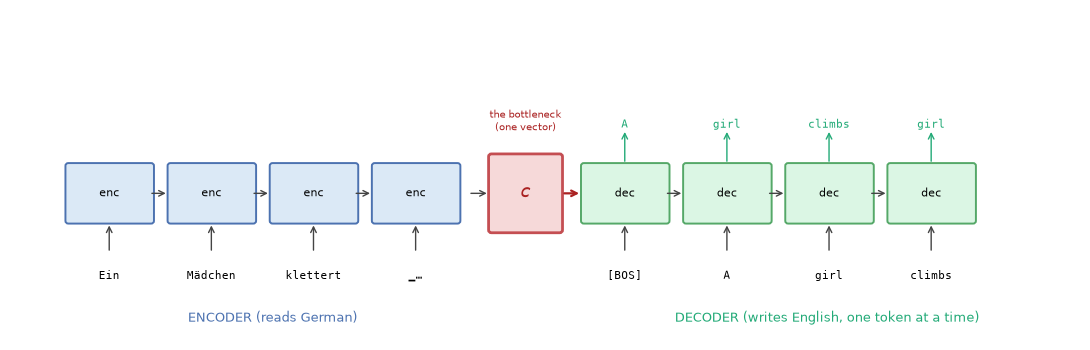

In [56]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def draw_seq2seq():
    src = ["Ein", "Mädchen", "klettert", "▁…"]; trg = ["[BOS]", "A", "girl", "climbs"]
    fig, ax = plt.subplots(figsize=(11, 3.6)); ax.axis("off")
    ax.set_xlim(0, 11); ax.set_ylim(0, 3.6)
    for i, t in enumerate(src):
        x = 0.6 + i * 1.05
        ax.add_patch(FancyBboxPatch((x, 1.3), 0.85, 0.6, boxstyle="round,pad=0.03", fc="#dbe9f6", ec="#4c72b0", lw=1.4))
        ax.text(x + 0.42, 1.6, "enc", ha="center", va="center", fontsize=8)
        ax.text(x + 0.42, 0.7, t, ha="center", va="center", fontsize=8, family="monospace")
        ax.annotate("", xy=(x + 0.42, 1.28), xytext=(x + 0.42, 0.95), arrowprops=dict(arrowstyle="->", color="#444"))
        if i: ax.annotate("", xy=(x - 0.02, 1.6), xytext=(x - 0.22, 1.6), arrowprops=dict(arrowstyle="->", color="#444"))
    bx = 0.6 + len(src) * 1.05 + 0.15
    ax.add_patch(FancyBboxPatch((bx, 1.2), 0.7, 0.8, boxstyle="round,pad=0.03", fc="#f6d9d9", ec="#c44e52", lw=2))
    ax.text(bx + 0.35, 1.6, "$c$", ha="center", va="center", fontsize=13, color="#a22")
    ax.text(bx + 0.35, 2.25, "the bottleneck\n(one vector)", ha="center", va="bottom", fontsize=7.5, color="#a22")
    ax.annotate("", xy=(bx - 0.02, 1.6), xytext=(bx - 0.24, 1.6), arrowprops=dict(arrowstyle="->", color="#444"))
    for i, t in enumerate(trg):
        x = bx + 0.95 + i * 1.05
        ax.add_patch(FancyBboxPatch((x, 1.3), 0.85, 0.6, boxstyle="round,pad=0.03", fc="#dbf6e4", ec="#55a868", lw=1.4))
        ax.text(x + 0.42, 1.6, "dec", ha="center", va="center", fontsize=8)
        ax.text(x + 0.42, 0.7, t, ha="center", va="center", fontsize=8, family="monospace")
        ax.annotate("", xy=(x + 0.42, 1.28), xytext=(x + 0.42, 0.95), arrowprops=dict(arrowstyle="->", color="#444"))
        if i: ax.annotate("", xy=(x - 0.02, 1.6), xytext=(x - 0.22, 1.6), arrowprops=dict(arrowstyle="->", color="#444"))
        else: ax.annotate("", xy=(x - 0.02, 1.6), xytext=(bx + 0.72, 1.6), arrowprops=dict(arrowstyle="->", color="#a22", lw=1.6))
        ax.text(x + 0.42, 2.35, trg[i + 1] if i + 1 < len(trg) else "girl", ha="center", va="center", fontsize=8, family="monospace", color="#2a7")
        ax.annotate("", xy=(x + 0.42, 2.3), xytext=(x + 0.42, 1.92), arrowprops=dict(arrowstyle="->", color="#2a7"))
    ax.text(2.7, 0.2, "ENCODER (reads German)", ha="center", fontsize=9, color="#4c72b0")
    ax.text(8.4, 0.2, "DECODER (writes English, one token at a time)", ha="center", fontsize=9, color="#2a7")
    plt.tight_layout(); plt.show()

draw_seq2seq()

Two implementation points the picture does not show:

* **The encoder is bidirectional.** It reads the German left-to-right *and* right-to-left, so its summary of each position sees the whole sentence. The two final states are concatenated (512 numbers) and projected down to the decoder's 256 — that projection is the bottleneck made concrete.
* **`pack_padded_sequence`.** The encoder must not read `[PAD]`. Packing tells cuDNN/PyTorch the true length of each sequence so the recurrence stops at the real end — the encoder equivalent of `ignore_index` in the loss.

The class is copied verbatim from `precompute.py`.

In [57]:
class Seq2SeqLSTM(nn.Module):
    '''Bidirectional LSTM encoder -> one vector -> LSTM decoder. No attention: the whole
    source sentence has to squeeze through (h0, c0).'''

    def __init__(self, src_vocab, trg_vocab, emb=256, hidden=256, dropout=0.2):
        super().__init__()
        self.hidden = hidden
        self.src_emb = nn.Embedding(src_vocab, emb, padding_idx=PAD)
        self.trg_emb = nn.Embedding(trg_vocab, emb, padding_idx=PAD)
        self.encoder = nn.LSTM(emb, hidden, batch_first=True, bidirectional=True)
        self.decoder = nn.LSTM(emb, hidden, batch_first=True)
        self.h_proj = nn.Linear(2 * hidden, hidden)
        self.c_proj = nn.Linear(2 * hidden, hidden)
        self.drop = nn.Dropout(dropout)
        self.out = nn.Linear(hidden, trg_vocab)

    def encode(self, src, src_len):
        e = self.drop(self.src_emb(src))
        packed = pack_padded_sequence(e, src_len.cpu(), batch_first=True, enforce_sorted=False)
        _, (h, c) = self.encoder(packed)                                 # h, c: (2, B, H) — forward & backward
        h = torch.tanh(self.h_proj(torch.cat([h[0], h[1]], dim=-1)))     # (B, H)  <- the bottleneck
        c = torch.tanh(self.c_proj(torch.cat([c[0], c[1]], dim=-1)))
        return h.unsqueeze(0), c.unsqueeze(0)

    def decode_step(self, y_prev, state):
        e = self.drop(self.trg_emb(y_prev))
        o, state = self.decoder(e, state)
        return self.out(self.drop(o)), state

    def forward(self, src, src_len, trg_in):
        state = self.encode(src, src_len)                # teacher forcing: decoder reads the gold prefix
        e = self.drop(self.trg_emb(trg_in))
        o, _ = self.decoder(e, state)
        return self.out(self.drop(o))

    @torch.no_grad()
    def greedy(self, src, src_len, max_len=40):
        state = self.encode(src, src_len)
        y = torch.full((src.size(0), 1), BOS, dtype=torch.long, device=src.device)
        out, done = [], torch.zeros(src.size(0), dtype=torch.bool, device=src.device)
        for _ in range(max_len):
            logits, state = self.decode_step(y, state)
            y = logits[:, -1].argmax(-1, keepdim=True).masked_fill(done.unsqueeze(1), PAD)
            out.append(y)
            done |= y.squeeze(1) == EOS
            if done.all(): break
        return torch.cat(out, dim=1)

## 5.2 Teacher forcing, and the bias it plants

Look again at `forward`. During training the decoder is fed the **gold** English prefix — the real previous word — no matter what it would have predicted. Say the gold translation is "I love cats": at every position the decoder gets the correct prefix regardless of its own guess — fed `[BOS]`, asked to predict `I`; fed `[BOS, I]`, asked to predict `love`; fed `[BOS, I, love]`, asked to predict `cats`. Even if it had guessed `You` instead of `I` at the first step, the second step still gets the gold `[BOS, I]`, not `[BOS, You]`. This is **teacher forcing**, and it is what makes training fast and stable: every position is an independent next-token classification with a guaranteed-correct prefix, and the whole target sequence trains in parallel.

But at *generation* time (`greedy`) there is no gold prefix to fall back on — the decoder must feed on its *own* previous output. So if it mispredicts `You` at step 1, step 2 now runs on `[BOS, You]` — a prefix it never once saw during training, since training only ever showed it correct prefixes. It has no learned behavior for that situation, so it tends to go further wrong from there, and the error compounds down the sequence. This train/test mismatch — correct prefixes always during training, self-generated (and possibly wrong) prefixes at test time — is **exposure bias** (Ranzato et al. 2015), and it is a big part of why these models drift on long outputs. Scheduled sampling and sequence-level training were proposed to fix it; in practice, attention and transformers reduced the drift enough that the community mostly stopped worrying about it.

## 5.3 Training


In [58]:
MAX_LEN = 50

def s2s_encode(src_texts, trg_texts):
    src = [torch.tensor(e.ids[:MAX_LEN], dtype=torch.long) for e in tok_de.encode_batch(src_texts)]
    trg = [torch.tensor([BOS] + e.ids[:MAX_LEN] + [EOS], dtype=torch.long) for e in tok_en.encode_batch(trg_texts)]
    return src, trg

def s2s_batches(src, trg, batch_size, shuffle):
    order = np.random.permutation(len(src)) if shuffle else np.arange(len(src))
    for i in range(0, len(src), batch_size):
        idx = order[i:i + batch_size]
        s = pad_sequence([src[j] for j in idx], batch_first=True, padding_value=PAD)
        t = pad_sequence([trg[j] for j in idx], batch_first=True, padding_value=PAD)
        s_len = torch.tensor([len(src[j]) for j in idx])
        yield s.to(device), s_len.to(device), t.to(device)

te_src, te_trg = s2s_encode(te_de, te_en)

if RECOMPUTE:
    !python precompute.py --data-dir data --out artifacts --only seq2seq

model = Seq2SeqLSTM(tok_de.get_vocab_size(), tok_en.get_vocab_size()).to(device)
model.load_state_dict(torch.load(f"{ART_DIR}/seq2seq_lstm.pt", map_location=device))
model.eval()
s2s_curves = json.load(open(f"{ART_DIR}/seq2seq_curves.json"))
print(f"loaded seq2seq: {s2s_curves['n_params'] / 1e6:.1f}M params, {s2s_curves['config']['epochs']} epochs, "
      f"test BLEU {s2s_curves['test_bleu']}")

loaded seq2seq: 8.0M params, 6 epochs, test BLEU 13.38


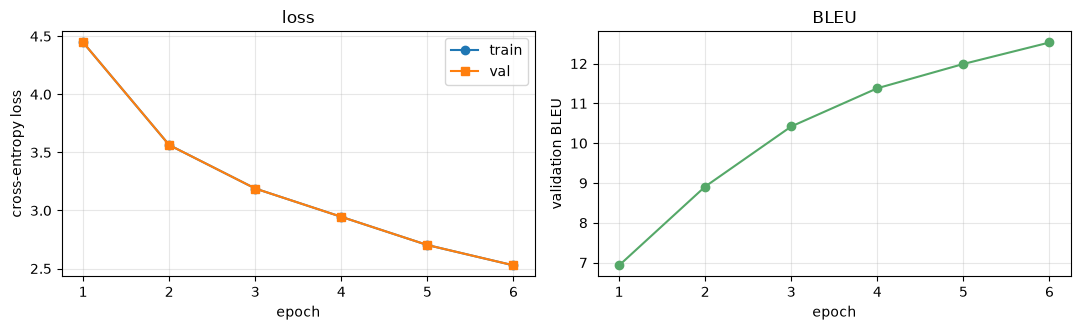

In [59]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
a1.plot(s2s_curves["epoch"], s2s_curves["train_loss"], "o-", label="train")
a1.plot(s2s_curves["epoch"], s2s_curves["val_loss"], "s-", label="val")
a1.set_xlabel("epoch"); a1.set_ylabel("cross-entropy loss"); a1.legend(); a1.grid(alpha=.3); a1.set_title("loss")
a2.plot(s2s_curves["epoch"], s2s_curves["val_bleu"], "o-", color="#55a868")
a2.set_xlabel("epoch"); a2.set_ylabel("validation BLEU"); a2.grid(alpha=.3); a2.set_title("BLEU")
plt.tight_layout(); plt.show()

## 5.4 BLEU: scoring a translation

Perplexity measured how well a model predicts *given* text; it cannot score a *generated* translation against a reference, because there are many correct translations and the model's own probability is not what we care about. The standard metric is **BLEU** (Papineni et al. 2002): what fraction of the generated n-grams (n = 1..4) appear in the reference, combined geometrically, times a **brevity penalty** that punishes translations shorter than the reference (otherwise emitting one very-likely word would score well).

$$\text{BLEU} = \underbrace{\min\!\big(1, e^{1 - r/c}\big)}_{\text{brevity penalty}} \cdot \Big(\prod_{n=1}^{4} p_n\Big)^{1/4}$$

BLEU is crude — it does not know synonyms, and a perfectly good paraphrase can score low — and it is the metric machine translation ran on for twenty years, because it correlates with human judgement *in aggregate*. The one rule that matters: BLEU implementations disagree (tokenization, smoothing), so you must use *one* implementation throughout. We use `sacrebleu`, which exists precisely to make the number reproducible.

In [60]:
import sacrebleu

def ids_to_text(tokz, ids):
    out = []
    for row in ids.tolist():
        cut = row.index(EOS) if EOS in row else len(row)
        out.append(tokz.decode([i for i in row[:cut] if i not in (PAD, BOS, EOS)]))
    return out

@torch.no_grad()
def translate_all(model, src, trg, batch_size=128):
    model.eval(); hyps = []
    for s, s_len, _ in s2s_batches(src, trg, batch_size, shuffle=False):
        hyps.extend(ids_to_text(tok_en, model.greedy(s, s_len)))
    return hyps

hyps = translate_all(model, te_src, te_trg)
bleu = sacrebleu.corpus_bleu(hyps, [te_en])
print(f"test BLEU (greedy): {bleu.score:.2f}\n")
for i in [0, 4, 11]:
    print(f"  DE:   {te_de[i]}\n  ref:  {te_en[i]}\n  ours: {hyps[i]}\n")

test BLEU (greedy): 13.38

  DE:   Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt.
  ref:  A man in an orange hat starring at something.
  ours: A man with a beard is looking at a camera.

  DE:   Leute Reparieren das Dach eines Hauses.
  ref:  People are fixing the roof of a house.
  ours: People are looking at a party.

  DE:   Männer, die Volleyball spielen, wobei ein Mann den Ball nicht trifft, während seine Hände immer noch in der Luft sind.
  ref:  Men playing volleyball, with one player missing the ball but hands still in the air.
  ours: Men, one man, one is playing the guitar while another man looks on the ground, while another man looks on.



The translations get the nouns right — the actors and objects survive — and often get the *action* wrong. "A man in a red shirt" becomes "a man in a blue shirt"; the participants make it through the bottleneck, the details do not. That is the fingerprint of the fixed-size summary: it has room for *what the sentence is about* but not for *everything it says*.

## 5.5 The bottleneck, measured

Two experiments make the bottleneck visible instead of asserted.

**First: BLEU as a function of input length.** If one vector is the limit, short sentences should translate well and long ones should fall off — because a longer sentence has more to cram through the same 256 numbers. We ran the sweep at three bottleneck widths (64, 128, 256) in `precompute.py`; here is BLEU per source-length bucket.

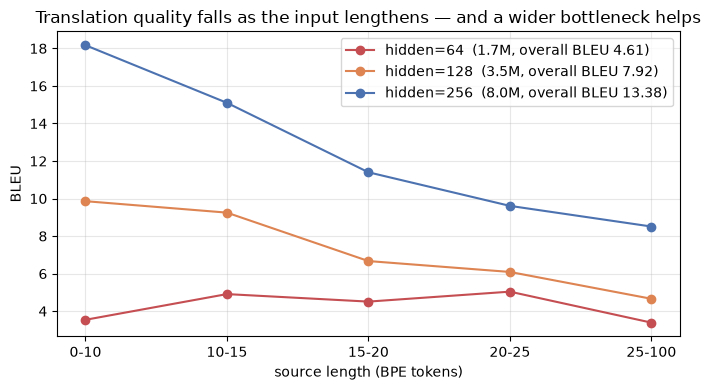

In [61]:
if RECOMPUTE:
    !python precompute.py --data-dir data --out artifacts --only sweep

sweep = json.load(open(f"{ART_DIR}/seq2seq_hidden_sweep.json"))

plt.figure(figsize=(7, 4))
for h, c in zip(["64", "128", "256"], ["#c44e52", "#dd8452", "#4c72b0"]):
    if h not in sweep: continue
    buckets = sweep[h]["bleu_by_src_len"]
    xs = list(range(len(buckets)))
    plt.plot(xs, list(buckets.values()), "o-", color=c,
             label=f"hidden={h}  ({sweep[h]['n_params'] / 1e6:.1f}M, overall BLEU {sweep[h]['test_bleu']})")
    plt.xticks(xs, list(buckets.keys()))
plt.xlabel("source length (BPE tokens)"); plt.ylabel("BLEU")
plt.title("Translation quality falls as the input lengthens — and a wider bottleneck helps")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

Two readings, and both point at next week:

* **The capable models slope down.** For hidden=256, BLEU falls steadily from short sentences to long ones — the longer the German, the more has to squeeze through the same 256 numbers, and the more the translation loses. This is the plot that motivates attention: Bahdanau et al. (2015) opens by showing exactly this decay and proposing to let the decoder look back at *all* encoder states instead of just the final one, which flattens the curve. (The hidden=64 line is flat because it is near the floor everywhere — a bottleneck that narrow barely translates *any* length, so there is no slope left to see. You need a model good enough to have something to lose.)
* **A wider bottleneck lifts the whole line.** Going 64 → 128 → 256 raises BLEU at every length. You can buy your way partly out of the bottleneck with more dimensions — but the downward slope is still there at 256, because the failure is architectural, not a matter of size. Attention removes the slope; width only raises the line.

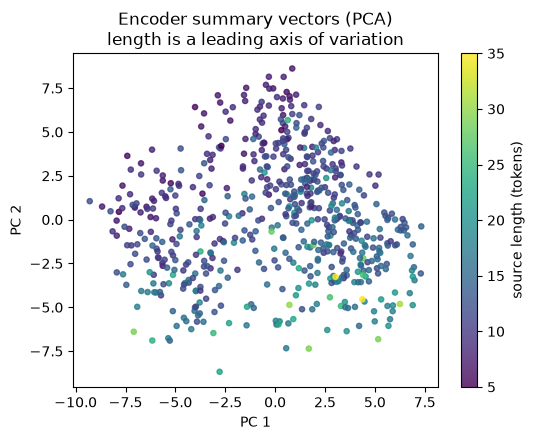

In [62]:
# Second: the bottleneck is a real vector — look at what it encodes.
# Colour each sentence's summary vector by its length; PCA to 2D.
@torch.no_grad()
def encode_vectors(model, src, trg, n=600):
    vecs, lens = [], []
    for s, s_len, _ in s2s_batches(src[:n], trg[:n], 128, shuffle=False):
        h, _ = model.encode(s, s_len)
        vecs.append(h[0].cpu()); lens.extend(s_len.tolist())
    return torch.cat(vecs).numpy(), np.array(lens)

vecs, lens = encode_vectors(model, te_src, te_trg)
vecs = vecs - vecs.mean(0)
U, S, Vt = np.linalg.svd(vecs, full_matrices=False)
xy = vecs @ Vt[:2].T

plt.figure(figsize=(5.5, 4.5))
sc = plt.scatter(xy[:, 0], xy[:, 1], c=lens, cmap="viridis", s=14, alpha=.8)
plt.colorbar(sc, label="source length (tokens)")
plt.title("Encoder summary vectors (PCA)\nlength is a leading axis of variation"); plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.tight_layout(); plt.show()

One of the first things the fixed-size summary spends its dimensions on is *sentence length* — which is real information, but it is telling that a leading axis of the "meaning" vector is bookkeeping. Sutskever et al. (2014) showed the same PCA revealed clusters by voice and word order; the point is that this vector is doing a lot of jobs with a fixed budget.

## 5.6 Beam search — now it earns its place

Back to block 4's cliffhanger. For open-ended jokes, the most-probable sequence was the *worst* output. For translation there **is** a right answer to approximate, so searching for the highest-probability sequence is exactly what we want — and beam search finds a much better one than greedy's one-token-at-a-time.

Beam search keeps the $b$ best partial translations, expands each by every possible next token, and keeps the $b$ best of all the extensions. The one subtlety is **length normalisation**: longer sequences multiply in more (log-)probabilities, all negative, so raw score favours short translations. We divide by length $^\alpha$ (Wu et al. 2016), $\alpha \approx 0.6$.

In [63]:
@torch.no_grad()
def beam_search(model, src_1, src_len_1, beam_width=5, max_len=40, alpha=0.6):
    '''src_1: (1, S) one sentence. Returns the best token-id list.'''
    state = model.encode(src_1, src_len_1)
    h, c = state
    beams = [([BOS], 0.0, (h, c))]                                    # (tokens, sum logprob, decoder state)
    finished = []
    for _ in range(max_len):
        candidates = []
        for tokens, score, st in beams:
            if tokens[-1] == EOS:
                finished.append((tokens, score)); continue
            y = torch.tensor([[tokens[-1]]], device=device)
            logits, st2 = model.decode_step(y, st)
            logp = torch.log_softmax(logits[0, -1], dim=-1)
            top_lp, top_i = logp.topk(beam_width)
            for lp, i in zip(top_lp.tolist(), top_i.tolist()):
                candidates.append((tokens + [i], score + lp, st2))
        if not candidates: break
        # length-normalised score for ranking
        candidates.sort(key=lambda x: x[1] / (len(x[0]) ** alpha), reverse=True)
        beams = candidates[:beam_width]
    finished += [(t, s) for t, s, _ in beams]
    best = max(finished, key=lambda x: x[1] / (len(x[0]) ** alpha))
    return best[0]


for i in [0, 4, 11]:
    s = te_src[i].unsqueeze(0).to(device); sl = torch.tensor([len(te_src[i])])
    g = ids_to_text(tok_en, model.greedy(s, sl))[0]
    b = ids_to_text(tok_en, torch.tensor([beam_search(model, s, sl, beam_width=5)]))[0]
    print(f"  DE:     {te_de[i]}\n  ref:    {te_en[i]}\n  greedy: {g}\n  beam-5: {b}\n")

  DE:     Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt.
  ref:    A man in an orange hat starring at something.
  greedy: A man with a beard is looking at a camera.
  beam-5: A man in a hat is looking at the camera.

  DE:     Leute Reparieren das Dach eines Hauses.
  ref:    People are fixing the roof of a house.
  greedy: People are looking at a party.
  beam-5: People waiting for a picture.

  DE:     Männer, die Volleyball spielen, wobei ein Mann den Ball nicht trifft, während seine Hände immer noch in der Luft sind.
  ref:    Men playing volleyball, with one player missing the ball but hands still in the air.
  greedy: Men, one man, one is playing the guitar while another man looks on the ground, while another man looks on.
  beam-5: Men, one in the foreground, one is playing the guitar while another man looks on.



In [65]:
# BLEU across a slice of the test set, for several beam widths (beam search on CPU is slow).
N_BEAM_EVAL = 200
rows = []
for bw in [1, 3, 5]:
    t = time.time()
    hyps_bw, refs_bw = [], te_en[:N_BEAM_EVAL]
    for i in range(N_BEAM_EVAL):
        s = te_src[i].unsqueeze(0).to(device); sl = torch.tensor([len(te_src[i])])
        ids = model.greedy(s, sl)[0].tolist() if bw == 1 else beam_search(model, s, sl, beam_width=bw)
        hyps_bw.append(ids_to_text(tok_en, torch.tensor([ids]))[0])
    rows.append({"beam width": bw, f"BLEU (first {N_BEAM_EVAL})": round(sacrebleu.corpus_bleu(hyps_bw, [refs_bw]).score, 2),
                 "seconds": round(time.time() - t, 1)})
beam_table = pd.DataFrame(rows)
beam_table

,beam width,BLEU (first 200),seconds
0,1,13.18,2.2
1,3,13.80,11.0
2,5,14.17,18.0


Wider beams find higher-probability translations and BLEU climbs — for a while. Then it flattens (and can even dip): beyond a point the extra probability is spent on making the translation *shorter and safer*, which is the same likelihood trap from block 4, milder because here probability and quality are better aligned. And every unit of beam width is a linear increase in compute. Beam 5 is the usual default; the table shows why nobody uses beam 50.

📌 **Bet answered:** beam search helped here (a right answer to approximate) and would have hurt on the jokes (no right answer, likelihood ≠ quality). Same algorithm, opposite verdict — because the *task* changed, not the decoder.

# 6. Where this goes

Put the results table back up and read it as one story.

In [66]:
show_results()

,model,tokens,test_ppl,bits/char,params,train_s,note
0,"3-gram, interpolated",words,3109.1,1.918,"622,154 counts",NaN,count-based
1,"3-gram, interpolated",BPE 8k,210.9,2.396,"865,574 counts",NaN,count-based
2,"LSTM, 8k jokes x 2 ep (live)",BPE 8k,492.8,2.776,4.6M,21.0,
3,"RNN, 12k jokes x 3 ep",BPE 8k,256.8,2.484,4.2M,123.0,precomputed
4,"GRU, 12k jokes x 3 ep",BPE 8k,252.3,2.476,4.5M,139.0,precomputed
5,"LSTM, 12k jokes x 3 ep",BPE 8k,309.5,2.567,4.6M,144.0,precomputed


Every row is the same equation — $P(\text{next token} \mid \text{prefix})$ х a decoding rule — with the left factor built a different way:

* **counting** (n-grams) is a strong, cheap baseline that generalises not at all — it memorises, and hits a wall the moment the test set contains an n-gram the training set did not. Well-smoothed, it beat our small networks on perplexity today;
* **a recurrent network** generalises through embeddings and an unbounded-in-principle state. At laptop scale it *matched* the smoothed trigram rather than beating it — but it writes novel text instead of reciting, its curve is still falling, and, decisively, it can be conditioned. The perplexity tie hides three advantages the count table can never have;
* **an encoder–decoder** conditions the whole thing on a second sequence, which is all translation, summarisation and dialogue ever were — bottlenecked by the one vector between the halves.

And the right factor turned out to carry as much weight as the left. Greedy maximises probability and produces the worst text; sampling with temperature and truncation reintroduces the jaggedness of real language; beam search is right for translation and wrong for jokes. None of that is about the model.

**Five things that transfer to every model this course will touch, GPT included:**

1. **Everything is next-token prediction.** The training loss is cross-entropy, which is $\log$ perplexity; the model outputs a distribution, and text is a second decision on top. Transformers change how $P$ is computed, not this frame.
2. **Perplexity is comparable only under a fixed tokenizer and test set** — and bits/char only lifts the tokenizer restriction for models that are lossless over the text. Off that, the number lies (a strong baseline can look weak, or a lossy one strong).
3. **The decoding rule is a design choice with its own failure modes.** temperature, top-p, min-p, repetition penalty, beam width — the same knobs on our 6M-parameter LSTM and on a 400B LLM.
4. **A fixed-size bottleneck loses information as the input grows, with a measurable slope.** That slope is next week's motivation.
5. **Likelihood is not quality.** The most probable continuation is usually not the one to show a human — the single most important thing decoding taught the field.

## 🏠 Homework (voluntary)

Everything marked 🏠 in the notebook runs as-is. Plus:

* **Kneser–Ney vs the neural LM.** Fit `nltk.lm.KneserNeyInterpolated` (or KenLM) at $n=5$ on the jokes and put it in the results table. How close does the best classical method get to the LSTM, per bits/char?
* **Weight tying and dropout** (block 3 homework) — get the LSTM's perplexity as low as you can in 10 epochs.
* **Scheduled sampling.** During seq2seq training, with probability $\epsilon$ feed the decoder its *own* previous prediction instead of the gold token, and anneal $\epsilon$. Does it reduce the drift on long test sentences (measure BLEU in the longest bucket)?
* **min-p at high temperature.** Reproduce the min-p paper's claim: at $T=2$, does min-p stay coherent where top-p falls apart? Use the repetition / distinct-2 table from 4.4.

## References

* Shannon (1948). [*A Mathematical Theory of Communication.*](https://doi.org/10.1002/j.1538-7305.1948.tb01338.x) Bell System Technical Journal 27.
* Jelinek, Mercer (1980). *Interpolated estimation of Markov source parameters from sparse data.* Pattern Recognition in Practice.
* Kneser, Ney (1995). [*Improved backing-off for m-gram language modeling.*](https://doi.org/10.1109/ICASSP.1995.479394) ICASSP.
* Gage (1994). *A New Algorithm for Data Compression.* C Users Journal. — BPE as compression.
* Sennrich, Haddow, Birch (2016). [*Neural Machine Translation of Rare Words with Subword Units.*](https://arxiv.org/abs/1508.07909) ACL.
* Bengio et al. (2003). [*A Neural Probabilistic Language Model.*](https://www.jmlr.org/papers/v3/bengio03a.html) JMLR 3.
* Elman (1990). [*Finding Structure in Time.*](https://doi.org/10.1207/s15516709cog1402_1) Cognitive Science 14.
* Mikolov et al. (2010). [*Recurrent neural network based language model.*](https://www.fit.vutbr.cz/research/groups/speech/publi/2010/mikolov_interspeech2010_IS100722.pdf) Interspeech.
* Hochreiter, Schmidhuber (1997). [*Long Short-Term Memory.*](https://doi.org/10.1162/neco.1997.9.8.1735) Neural Computation 9(8).
* Cho et al. (2014). [*Learning Phrase Representations using RNN Encoder–Decoder.*](https://arxiv.org/abs/1406.1078) EMNLP. — GRU and the encoder–decoder.
* Chung et al. (2014). [*Empirical Evaluation of Gated Recurrent Neural Networks.*](https://arxiv.org/abs/1412.3555) arXiv.
* Bengio et al. (1994). [*Learning Long-Term Dependencies with Gradient Descent is Difficult.*](https://doi.org/10.1109/72.279181) IEEE TNN 5(2).
* Pascanu, Mikolov, Bengio (2013). [*On the difficulty of training recurrent neural networks.*](https://arxiv.org/abs/1211.5063) ICML. — gradient clipping.
* Press, Wolf (2017). [*Using the Output Embedding to Improve Language Models.*](https://arxiv.org/abs/1608.05859) EACL. — weight tying.
* Sutskever, Vinyals, Le (2014). [*Sequence to Sequence Learning with Neural Networks.*](https://arxiv.org/abs/1409.3215) NeurIPS.
* Papineni et al. (2002). [*BLEU: a Method for Automatic Evaluation of Machine Translation.*](https://aclanthology.org/P02-1040/) ACL.
* Post (2018). [*A Call for Clarity in Reporting BLEU Scores.*](https://arxiv.org/abs/1804.08771) WMT. — `sacrebleu`.
* Ranzato et al. (2015). [*Sequence Level Training with Recurrent Neural Networks.*](https://arxiv.org/abs/1511.06732) ICLR. — exposure bias.
* Fan, Lewis, Dauphin (2018). [*Hierarchical Neural Story Generation.*](https://arxiv.org/abs/1805.04833) ACL. — top-k.
* Holtzman et al. (2019). [*The Curious Case of Neural Text Degeneration.*](https://arxiv.org/abs/1904.09751) ICLR 2020. — nucleus sampling.
* Keskar et al. (2019). [*CTRL: A Conditional Transformer Language Model.*](https://arxiv.org/abs/1909.05858) — repetition penalty.
* Nguyen et al. (2024). [*Turning Up the Heat: Min-p Sampling for Creative and Coherent LLM Outputs.*](https://arxiv.org/abs/2407.01082) arXiv.
* Wu et al. (2016). [*Google's Neural Machine Translation System.*](https://arxiv.org/abs/1609.08144) arXiv. — length-normalised beam search.
* Bahdanau, Cho, Bengio (2015). [*Neural Machine Translation by Jointly Learning to Align and Translate.*](https://arxiv.org/abs/1409.0473) ICLR. — attention, next week.